# Extensions

The notebook uses code from `\src`, which is separated into ``models`` and ``estimation``. 

Classes in ``models`` are defined to include the methods necessary to 
a. generate synthetic data of given model parameters
b. compute the log-likelihood of synthetic data
c. parameter unconstrain, constrain, and update functions for MCMC

Classes in ``estimation`` are defined to include the methods necessary to filter for latent state given observations and to estimate model parameters from observation data. Latent state filtering methods take in models with preset parameters and data, and return the filtered latent states. Parameter estimation methods take in the model and data, and return the estimated model parameters. MCMC methods return a chain of parameter estimates.

### Particle Filter Project — Extension Results

This notebook presents the full empirical study accompanying the particle filter project. It is structured in nine sections covering filtering, estimation, and model extensions for linear Gaussian and regime-switching state-space models.

---

### Simple Linear State Space Model

The base model is a 1-D linear Gaussian AR(1) state-space model:

$$x_t = \phi\, x_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2)$$
$$y_t = \alpha\, x_t + \nu_t, \quad \nu_t \sim \mathcal{N}(0,\, \tau^2)$$

with initial distribution $x_0 \sim \mathcal{N}(0, P_0)$. The Kalman filter provides the exact marginal likelihood and filtered state, serving as the reference benchmark. Later sections extend to a two-regime Markov-switching model in which $\sigma^2$ is regime-dependent.

---

### Codebase

| Directory | Purpose |
|---|---|
| `src/models/` | State-space models: `SimpleLinearGaussianSSM`, `FixedAlphaSSM`, `SimpleRegimeSwitchingSSM`, `LinearTSSM`, `LinearARMASSM` |
| `src/estimation/` | Filtering: `KalmanFilter`, `ParticleFilter`, `RaoBlackwellizedParticleFilter`; Estimation: `MLEEstimator`, `MetropolisHastings`, `HamiltonianMC`, `PMMH`, `BlockPMMH`, `NelderMeadPMMLE` |
| `src/utils.py` | `rmse`, `chain_ess`, `logsumexp`, `timer`, helper functions |

---

### Contents

| Section | Topic | Methods |
|---|---|---|
| **I**   | Basic filtering under true parameters | Kalman filter, bootstrap PF |
| **II**  | PF sensitivity analysis | N-particles, noise ratio σ²/τ², resampling strategy |
| **III** | Basic parameter estimation | MLE, MH, Nelder-Mead PMMLE, HMC |
| **IV**  | MCMC diagnostics and robustness | Convergence, misspecified α, hypothesis testing |
| **V**   | PMMH and Blocked PMMH | Naive vs. blocked particle MCMC |
| **VI**  | Regime-switching model: filtering | Two-regime SSM, RBPF filtering and regime detection |
| **VII** | Regime-switching model: estimation | Nelder-Mead RBPF-PMLE, RBPF-PMMH |
| **IX**  | Model misspecification | Gaussian fit on student-t and ARMA data |

---

In [1]:
# Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM, FixedAlphaSSM

# Filtering methods
from estimation.kalman_filter import KalmanFilter
from estimation.particle_filter import ParticleFilter

from estimation.resampling_methods import SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling 
# SystematicResampling will be the default for ParticleFilter

# Parameter Estimation methods
from estimation.mle_estimator import MLEEstimator
from estimation.nelder_mead import NelderMeadPMMLE
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.pmmh import PMMH, BlockPMMH

# Helpers
from estimation.kde import KDE
from utils import rmse, chain_ess, ess_trajectory

# Regime-switching models
from models.regime_switching_simple import SimpleRegimeSwitchingSSM, FixedAlphaRS
from estimation.rbpf import RaoBlackwellizedParticleFilter

# Other state-space models
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Section I: Basic results (Filtering)

We establish the baseline filtering setup for a 1-D linear Gaussian AR(1) model. The Kalman filter provides the exact marginal likelihood and filtered state estimates, which serve as the benchmark throughout the notebook. The bootstrap particle filter is run under the same true parameters to verify agreement.

1. Synthetic data generation using the linear state-space model
2. Kalman filter (exact) and particle filter filtering under true parameters — RMSE and log-likelihood comparison
3. Particle cloud visualisation

In [2]:
# true params
phi_true = 0.9
alpha_true = 1.5
sigma2_true = 0.25 # Parameterized using variance
tau2_true = 1.0 # Parameterized using variance

TRUE_PARAMS = {'phi': phi_true, 'alpha': alpha_true, 'sigma2': sigma2_true, 'tau2': tau2_true}

initial_var_fixed = 1.0

T = 200

SEED = 42

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma2=sigma2_true, tau2=tau2_true, initial_var = initial_var_fixed, seed= SEED) 
# Note that in the current implementation, when initial variance is provided, it is treated as an a priori hyperparameter and fixed throughout the simulation. It is not updated in parameter estimation
# If initial variance is not provided, the initial variance uses the default stationary distribution variance (sigma^2 / (1 - phi^2)), which is updated in parameter estimation.
print(model)

SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0)


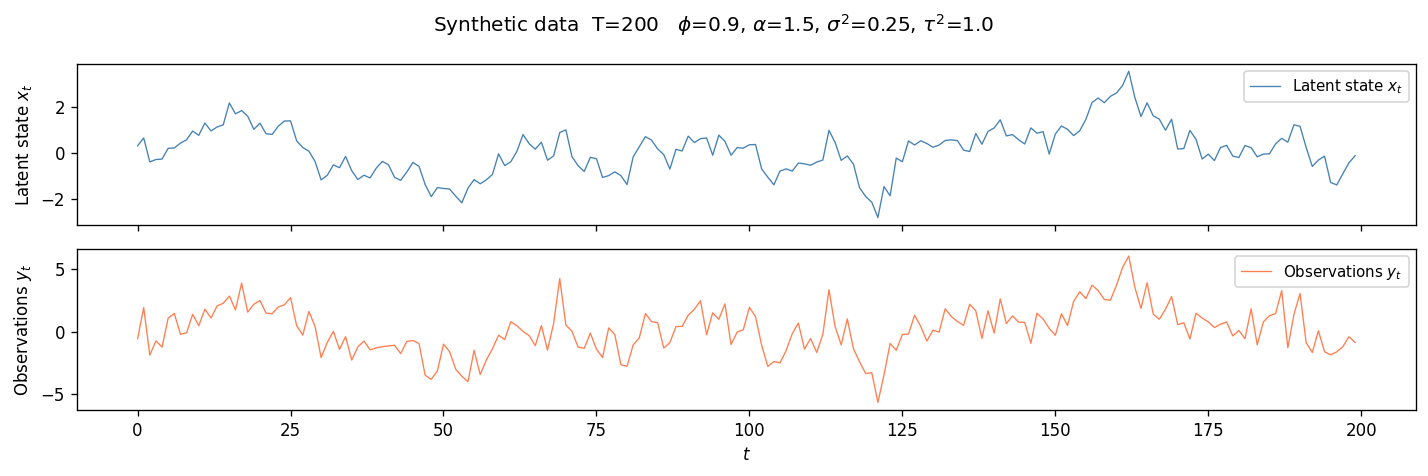

true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: -267.41


In [3]:
# Generate Synthetic Data
states, observations, true_loglik = model.generate_data(T)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(states.ravel(), lw=0.8, color='steelblue', label='Latent state $x_t$')
axes[1].plot(observations.ravel(), lw=0.8, color='coral',     label='Observations $y_t$')
for ax in axes:
    ax.legend(fontsize=9)
    ax.set_ylabel(ax.get_legend().get_texts()[0].get_text())
axes[1].set_xlabel('$t$')
fig.suptitle(f'Synthetic data  T={T}   '
             rf'$\phi$={phi_true}, $\alpha$={alpha_true}, '
             rf'$\sigma^2$={sigma2_true}, $\tau^2$={tau2_true}')
plt.tight_layout()
plt.show()
print(f"true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: {true_loglik:.2f}")


In [4]:
# Kalman filter (exact benchmark) — requires LinearGaussianSSM
kf_model = LinearGaussianSSM(
    a=np.array([[phi_true]]),
    c=np.array([[alpha_true]]),
    q=np.array([[sigma2_true]]),
    r=np.array([[tau2_true]]),
    p_0=np.array([[initial_var_fixed]])
)
kf = KalmanFilter(kf_model, observations)
kf_means, kf_covs, kf_loglik = kf.run_filter()
kf_states = kf_means.ravel()
kf_stds   = np.sqrt(kf_covs.ravel())

In [5]:
N_PARTICLES = 5000

# Particle filter
pf = ParticleFilter(model=model, N_particles=N_PARTICLES, data=observations,
                    resample_method=SystematicResampling(seed=SEED))
pf_states, p_his, w_his, rs_his, pf_loglik = pf.run_filter()
ess_traj = ess_trajectory(pf)

pf_states = pf_states.ravel()

In [6]:
kf_rmse = rmse(states.ravel(), kf_states)
pf_rmse = rmse(states.ravel(), pf_states)
print("True Log-likelihood log p(y | x_true, theta)")
print(f"Log-likelihood (true): {true_loglik:.2f}")
print()
print("Marginal Log-likelihoods log p(y | theta)")
print(f"Log-likelihood — KF (exact): {kf_loglik:.2f}")
print(f"Log-likelihood — PF estimate (N={N_PARTICLES}): {pf_loglik:.2f}")
print()
print(f"RMSE — KF: {kf_rmse:.4f}")
print(f"RMSE — PF: {pf_rmse:.4f}")

True Log-likelihood log p(y | x_true, theta)
Log-likelihood (true): -267.41

Marginal Log-likelihoods log p(y | theta)
Log-likelihood — KF (exact): -341.78
Log-likelihood — PF estimate (N=5000): -342.05

RMSE — KF: 0.4074
RMSE — PF: 0.4076


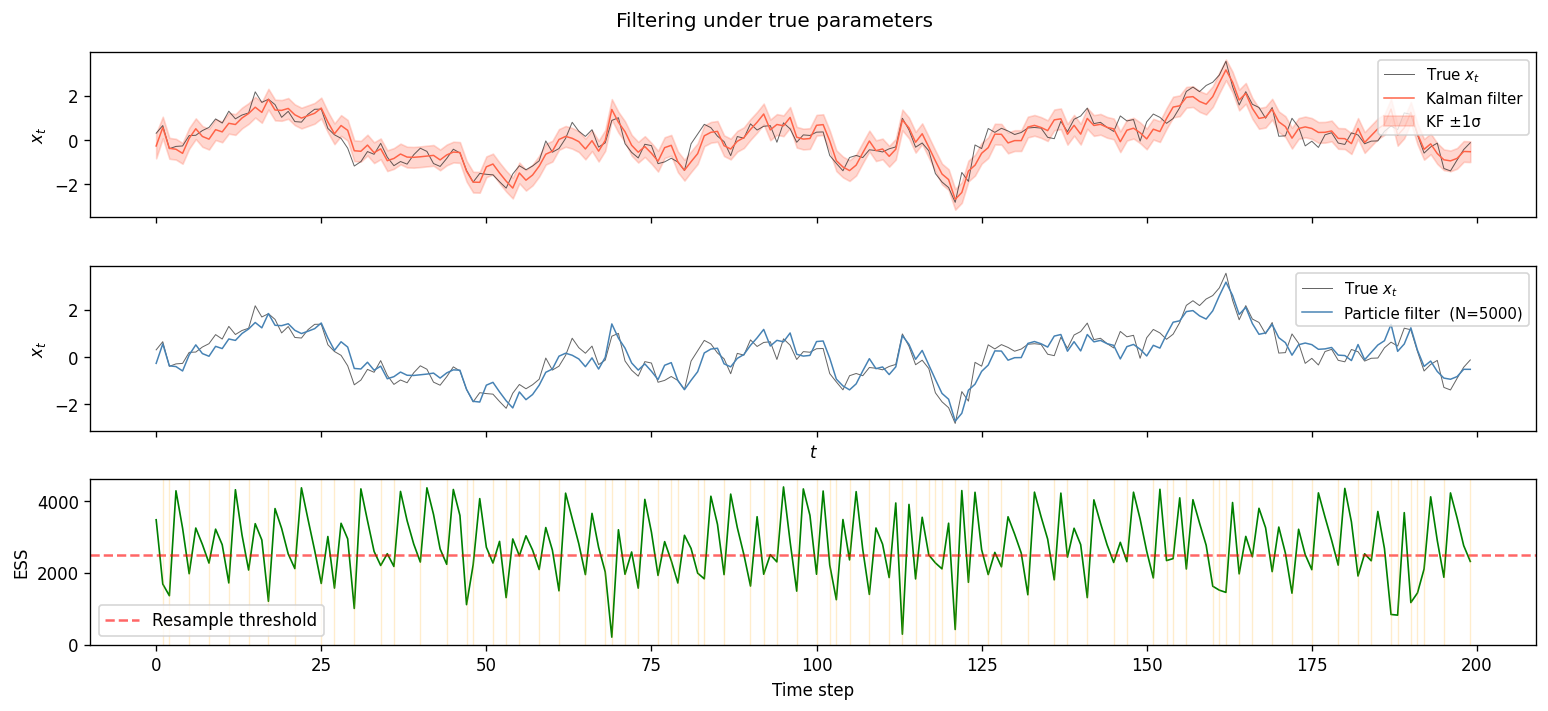

In [7]:
t_plot = np.arange(T)
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

for ax, est, label, color in [
    (axes[0], kf_states, 'Kalman filter', 'tomato'),
    (axes[1], pf_states, f'Particle filter  (N={N_PARTICLES})', 'steelblue'),
]:
    ax.plot(states.ravel(), lw=0.6, color='black', alpha=0.6, label='True $x_t$')
    ax.plot(est, lw=0.9, color=color, label=label)
    if color == 'tomato':                        # add KF ±1σ band
        ax.fill_between(t_plot, kf_states - kf_stds, kf_states + kf_stds,
                        alpha=0.25, color=color, label='KF ±1σ')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('$x_t$')

axes[1].set_xlabel('$t$')
fig.suptitle('Filtering under true parameters')

axes[2].plot(ess_traj, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rs_his) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()

plt.tight_layout()
plt.show()


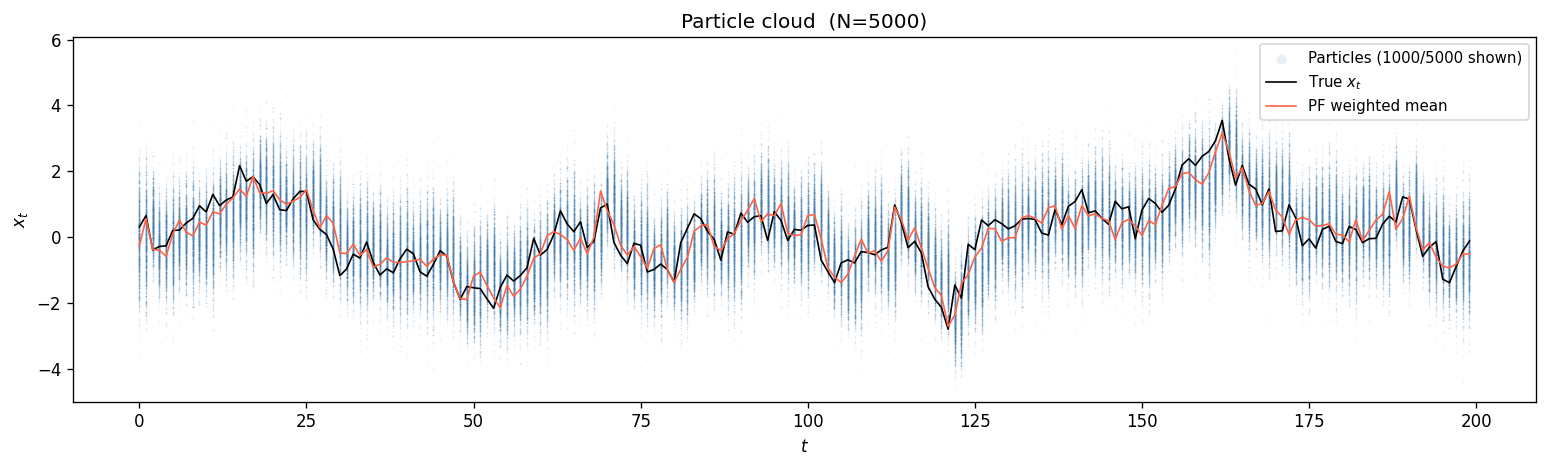

In [8]:
# Plot particle cloud (marginal filtering distribution at each timestep)
N_SHOW  = 1000   # particles sampled per timestep (out of N_PARTICLES)
rng_vis = np.random.default_rng(0)
t_plot  = np.arange(T)

t_scatter = np.repeat(t_plot, N_SHOW)
x_scatter = np.concatenate([
    p_his[t][rng_vis.choice(N_PARTICLES, N_SHOW, replace=False)]
    for t in t_plot
])

fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(t_scatter, x_scatter, s=1, alpha=0.12, color='steelblue',
           linewidths=0, label=f'Particles ({N_SHOW}/{N_PARTICLES} shown)')
ax.plot(states.ravel(), lw=1.0, color='black',  label='True $x_t$')
ax.plot(pf_states,      lw=1.0, color='tomato', label='PF weighted mean')
ax.set_xlabel('$t$')
ax.set_ylabel('$x_t$')
ax.legend(fontsize=9, loc='upper right', markerscale=6)
ax.set_title(f'Particle cloud  (N={N_PARTICLES})')
plt.tight_layout()
plt.show()

## Section II: Particle Filter More Detailed Results

The bootstrap particle filter's performance depends on three key design choices: the number of particles N, the noise regime (σ²/τ²), and the resampling strategy. Using the Kalman filter as an exact reference, this section examines each factor in isolation.

1. Effect of N on RMSE and log-likelihood variance (expected: std ∝ 1/√N)
2. Noise sensitivity: filtering accuracy across the σ²/τ² signal-to-noise range
3. Resampling method comparison: systematic, stratified, residual, multinomial
4. Conclusion: recommended N and resampling strategy

### 1. Effect of Number of Particles

Larger N reduces the Monte Carlo variance of the PF log-likelihood estimate and improves filtered state accuracy, at proportionally higher compute cost. We run `N_reps` repeated trials at each N to measure the mean and standard deviation of both RMSE and log-likelihood, plotting the convergence toward the Kalman filter reference.

Estimated runtime: 5~15 min

In [9]:
N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
N_reps   = 10

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for N_p in N_values:
    for rep in range(N_reps):
        pf_n = ParticleFilter(model=model, N_particles=N_p, data=observations,
                              resample_method=SystematicResampling(seed=rep))
        pf_latent, _, _, _, ll_n = pf_n.run_filter()
        rmse_by_N[N_p].append(rmse(states.ravel(), pf_latent))
        loglik_by_N[N_p].append(ll_n)
    print(f"N={N_p:6d}  RMSE={np.mean(rmse_by_N[N_p]):.4f} ± {np.std(rmse_by_N[N_p]):.4f}"
          f"  loglik={np.mean(loglik_by_N[N_p]):.2f} ± {np.std(loglik_by_N[N_p]):.2f}")

N=    25  RMSE=0.4314 ± 0.0051  loglik=-345.74 ± 3.24
N=    50  RMSE=0.4165 ± 0.0101  loglik=-343.96 ± 2.28
N=   100  RMSE=0.4135 ± 0.0060  loglik=-342.75 ± 1.04
N=   250  RMSE=0.4079 ± 0.0031  loglik=-341.98 ± 1.13
N=   500  RMSE=0.4086 ± 0.0017  loglik=-342.12 ± 0.52
N=  1000  RMSE=0.4072 ± 0.0010  loglik=-341.88 ± 0.35
N=  2500  RMSE=0.4072 ± 0.0008  loglik=-341.86 ± 0.26
N=  5000  RMSE=0.4073 ± 0.0005  loglik=-341.79 ± 0.30
N= 10000  RMSE=0.4075 ± 0.0006  loglik=-341.79 ± 0.10


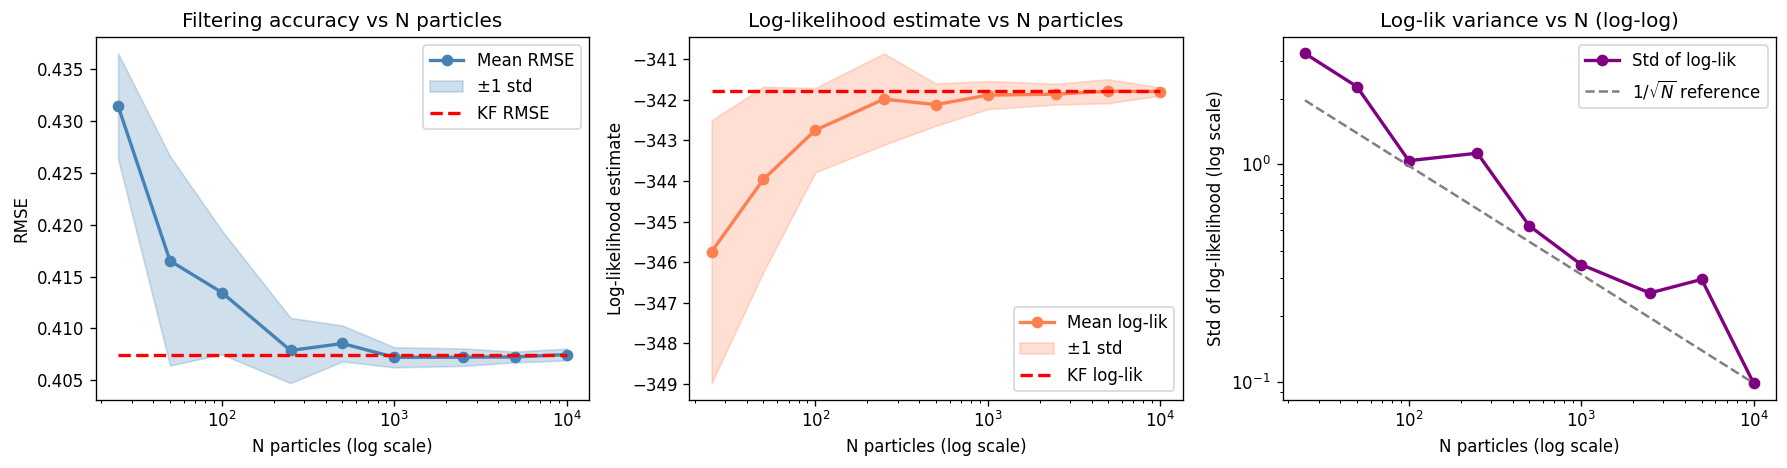

In [10]:
# Reference RMSE and log likelihood from Kalman Filter are stored in kf_rmse and kf_loglik
rmse_mean   = np.array([np.mean(rmse_by_N[n]) for n in N_values])
rmse_std    = np.array([np.std(rmse_by_N[n]) for n in N_values])
loglik_mean = np.array([np.mean(loglik_by_N[n]) for n in N_values])
loglik_std  = np.array([np.std(loglik_by_N[n]) for n in N_values])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].semilogx(N_values, kf_rmse * np.ones(len(N_values)), '--', color = 'red', lw=2, label = 'KF RMSE')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, kf_loglik * np.ones(len(N_values)), '--', color='red', lw=2, label='KF log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

We see that RMSE and log-likelihood from Particle Filter estimates converge to Kalman Filter values as $N \to \infty$. The standard deviation of PF log-likelihood estimate is proportional to $1/\sqrt{N}$, as expected.

### 2. Noise Sensitivity

We sweep the signal-to-noise ratio σ²/τ² by varying σ (process noise) while holding τ (observation noise) fixed at several values. Both PF and KF are evaluated over `n_reps_r` independent data draws per noise level, so the results reflect average filtering difficulty rather than a single dataset. The log-likelihood bias and variability of the PF relative to the KF reveal where Monte Carlo noise matters most.

In [11]:
# Sweep σ so r = σ²/τ² ∈ [0.01, 9]; repeat for several τ values and plot as separate lines.
phi_r    = 0.9
alpha_r  = 1.0
N_r      = 200 # Number of particles
T_r      = 200
n_reps_r = 10  # Number of repeated trials for data generation and filtering

tau_r_vals   = [0.5, 1.0, 2.0, 4.0]
sigma_r_vals = np.logspace(-1, np.log10(3.0), 5)   # sigma 0.1 … 3.0

results_by_tau = {}
rng_r = np.random.default_rng(77)

for tau_r in tau_r_vals:
    ratio_vals       = sigma_r_vals ** 2 / tau_r ** 2
    pf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_rmse_std      = np.zeros(len(sigma_r_vals))
    kf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_loglik_mean   = np.zeros(len(sigma_r_vals))
    pf_loglik_std    = np.zeros(len(sigma_r_vals))
    kf_loglik_mean   = np.zeros(len(sigma_r_vals))
    loglik_bias_mean = np.zeros(len(sigma_r_vals))
    loglik_bias_std  = np.zeros(len(sigma_r_vals))

    for i, sigma_r in enumerate(sigma_r_vals):
        pf_rmse_i   = []
        kf_rmse_i   = []
        pf_loglik_i = []
        kf_loglik_i = []

        for rep in range(n_reps_r):
            seed_r = int(rng_r.integers(0, 10**6))
            m_r = SimpleLinearGaussianSSM(phi=phi_r, alpha=alpha_r,
                                          sigma2=sigma_r**2, tau2=tau_r**2,
                                          initial_var=initial_var_fixed, seed=seed_r)
            s_r, o_r, _ = m_r.generate_data(T_r)
            obs_r  = o_r[:, 0]
            true_r = s_r[:, 0]

            pf_r = ParticleFilter(model=m_r, N_particles=N_r, data=obs_r,
                                  resample_method=SystematicResampling(seed=rep))
            pf_r_latent, _, _, _, pf_r_loglik = pf_r.run_filter()
            pf_rmse_i.append(rmse(true_r, pf_r_latent))
            pf_loglik_i.append(pf_r_loglik)

            kf_m = LinearGaussianSSM(
                a=np.array([[phi_r]]),
                c=np.array([[alpha_r]]),
                q=np.array([[sigma_r ** 2]]),
                r=np.array([[tau_r ** 2]]),
                p_0=np.array([[initial_var_fixed]])
            )
            kf_r = KalmanFilter(model=kf_m, data=obs_r)
            filt_m, _, kf_r_loglik = kf_r.run_filter()
            kf_rmse_i.append(rmse(true_r, filt_m[:, 0]))
            kf_loglik_i.append(kf_r_loglik)

        bias_i = [p - k for p, k in zip(pf_loglik_i, kf_loglik_i)]

        pf_rmse_mean[i]     = np.mean(pf_rmse_i)
        pf_rmse_std[i]      = np.std(pf_rmse_i)
        kf_rmse_mean[i]     = np.mean(kf_rmse_i)
        pf_loglik_mean[i]   = np.mean(pf_loglik_i)
        pf_loglik_std[i]    = np.std(pf_loglik_i)
        kf_loglik_mean[i]   = np.mean(kf_loglik_i)
        loglik_bias_mean[i] = np.mean(bias_i)
        loglik_bias_std[i]  = np.std(bias_i)

    results_by_tau[tau_r] = dict(
        ratio=ratio_vals,
        pf_rmse_mean=pf_rmse_mean,
        pf_rmse_std=pf_rmse_std,
        kf_rmse_mean=kf_rmse_mean,
        pf_loglik_mean=pf_loglik_mean,
        pf_loglik_std=pf_loglik_std,
        kf_loglik_mean=kf_loglik_mean,
        loglik_bias_mean=loglik_bias_mean,
        loglik_bias_std=loglik_bias_std,
    )
    print(f"\u03c4\u00b2={tau_r**2:.2f}  done")


τ²=0.25  done
τ²=1.00  done
τ²=4.00  done
τ²=16.00  done


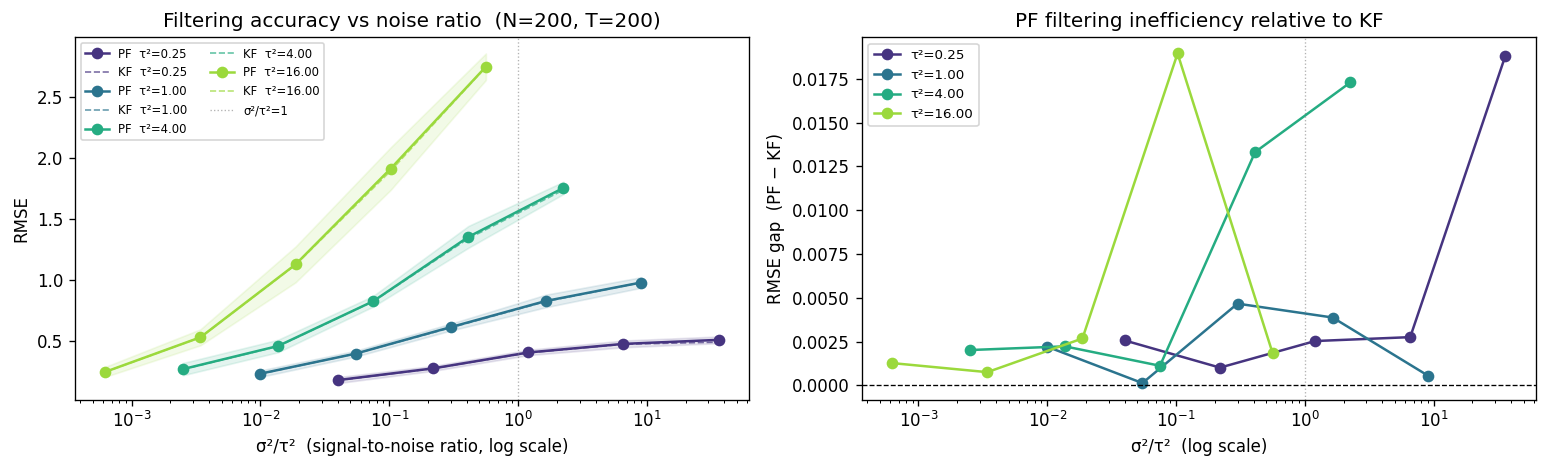

In [12]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tau_r, col in zip(tau_r_vals, colors):
    r   = results_by_tau[tau_r]
    lbl = f'τ²={tau_r**2:.2f}'

    # PF mean ± 1 std
    axes[0].semilogx(r['ratio'], r['pf_rmse_mean'], 'o-', color=col, lw=1.5, label=f'PF  {lbl}')
    axes[0].fill_between(r['ratio'],
                         r['pf_rmse_mean'] - r['pf_rmse_std'],
                         r['pf_rmse_mean'] + r['pf_rmse_std'],
                         alpha=0.12, color=col)
    # KF as dashed reference
    axes[0].semilogx(r['ratio'], r['kf_rmse_mean'], '--', color=col, lw=1.0, alpha=0.7,
                     label=f'KF  {lbl}')

    # RMSE gap: PF - KF (filtering inefficiency)
    gap = r['pf_rmse_mean'] - r['kf_rmse_mean']
    axes[1].semilogx(r['ratio'], gap, 'o-', color=col, lw=1.5, label=lbl)

axes[0].axvline(1.0, color='grey', lw=0.8, ls=':', alpha=0.6, label='σ²/τ²=1')
axes[0].set_xlabel('σ²/τ²  (signal-to-noise ratio, log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title(f'Filtering accuracy vs noise ratio  (N={N_r}, T={T_r})')
axes[0].legend(fontsize=7, ncol=2)

axes[1].axhline(0,   color='black', lw=0.8, ls='--')
axes[1].axvline(1.0, color='grey',  lw=0.8, ls=':', alpha=0.6)
axes[1].set_xlabel('σ²/τ²  (log scale)')
axes[1].set_ylabel('RMSE gap  (PF − KF)')
axes[1].set_title('PF filtering inefficiency relative to KF')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [13]:
# Print report: log-likelihood bias (PF − KF) across noise regimes
print(f"Log-likelihood bias  E[PF − KF]   N_particles={N_r}, T={T_r}, reps={n_reps_r}\n")
step = max(1, len(sigma_r_vals) // 8)

for tau_r in tau_r_vals:
    r = results_by_tau[tau_r]
    print(f"\u03c4\u00b2 = {tau_r**2:.2f}")
    print(f"  {'\u03c3\u00b2/\u03c4\u00b2':>8}  {'KF loglik':>10}  {'PF loglik':>10}  {'Bias':>8}  {'PF std':>7}")
    print(f"  {'-' * 50}")
    for j in range(0, len(r['ratio']), step):
        print(f"  {r['ratio'][j]:8.3f}  {r['kf_loglik_mean'][j]:10.2f}  "
              f"{r['pf_loglik_mean'][j]:10.2f}  {r['loglik_bias_mean'][j]:8.2f}  "
              f"{r['pf_loglik_std'][j]:7.2f}")
    print()


Log-likelihood bias  E[PF − KF]   N_particles=200, T=200, reps=10

τ² = 0.25
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.040     -161.57     -161.82     -0.25     7.54
     0.219     -188.02     -188.04     -0.02    14.09
     1.200     -247.63     -248.83     -1.20     9.62
     6.573     -355.68     -357.76     -2.07     9.53
    36.000     -510.40     -518.47     -8.06    10.96

τ² = 1.00
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.010     -290.53     -290.49      0.05    11.24
     0.055     -301.11     -301.09      0.02     6.23
     0.300     -325.12     -326.18     -1.07     9.20
     1.643     -394.14     -394.94     -0.80     7.39
     9.000     -512.23     -513.78     -1.55    10.78

τ² = 4.00
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.003     -416.66     -416.69     -

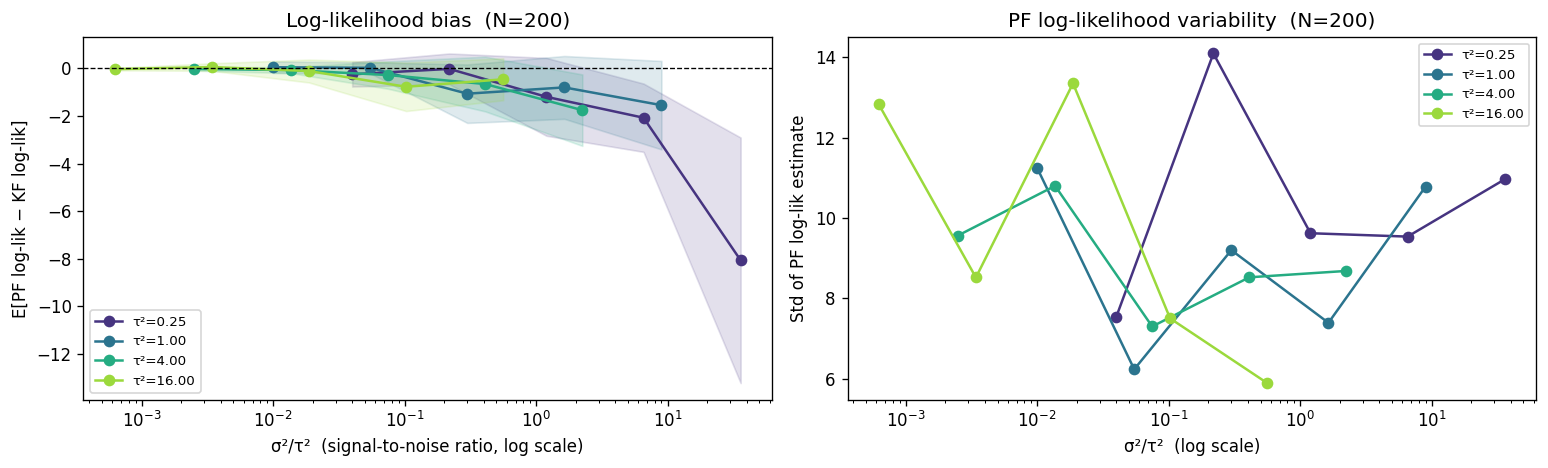

In [14]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tau_r, col in zip(tau_r_vals, colors):
    r = results_by_tau[tau_r]
    lbl = f'\u03c4\u00b2={tau_r**2:.2f}'

    # Bias (mean ± 1 std)
    axes[0].semilogx(r['ratio'], r['loglik_bias_mean'], 'o-', color=col, lw=1.5, label=lbl)
    axes[0].fill_between(r['ratio'],
                         r['loglik_bias_mean'] - r['loglik_bias_std'],
                         r['loglik_bias_mean'] + r['loglik_bias_std'],
                         alpha=0.15, color=col)

    # PF log-lik std
    axes[1].semilogx(r['ratio'], r['pf_loglik_std'], 'o-', color=col, lw=1.5, label=lbl)

axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (signal-to-noise ratio, log scale)')
axes[0].set_ylabel('E[PF log-lik \u2212 KF log-lik]')
axes[0].set_title(f'Log-likelihood bias  (N={N_r})')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (log scale)')
axes[1].set_ylabel('Std of PF log-lik estimate')
axes[1].set_title(f'PF log-likelihood variability  (N={N_r})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 3. Effect of Resampling Method Choice

The resampling step resets degenerate weight distributions but introduces discrete variance. Systematic and stratified resampling are lower-variance alternatives to multinomial resampling; residual resampling uses a deterministic first pass. We compare all four on identical data across 30 seeds at N=500.

In [15]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = T
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, initial_var = initial_var_fixed, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        pf_states, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
        rmse_rs[name].append(rmse(s[:, 0], pf_states))
        loglik_rs[name].append(ll)

In [16]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

Method         RMSE mean   RMSE std   loglik mean  loglik std
------------------------------------------------------------
Systematic       0.5843     0.0542       -328.69★       8.35 
Stratified       0.5839★    0.0534★      -329.02        8.31 
Residual         0.5841     0.0542       -329.18        8.21 
Multinomial      0.5844     0.0552       -328.99        8.20★


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_77366/3169042032.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_77366/3169042032.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([loglik_rs[n] for n in names], labels=names)


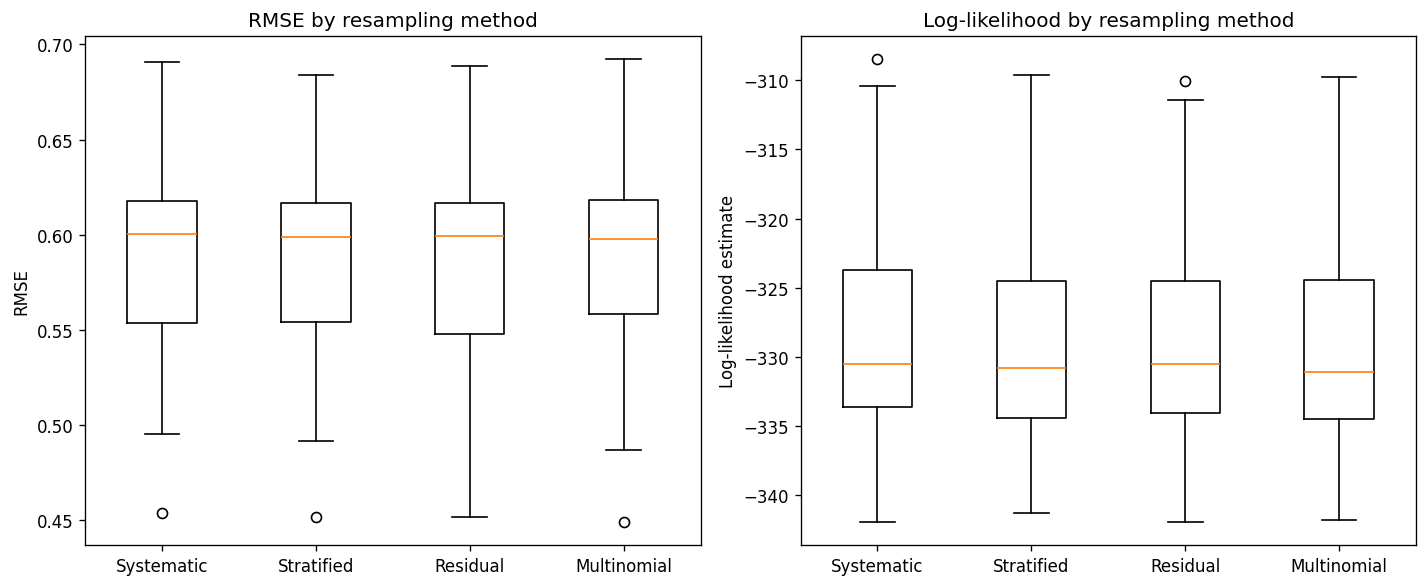

In [17]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

### 4. Conclusion

Choose `Systematicmpling` or `StratifiedResampling` as resampling method. For current synthetic data, around N_particles = 1000 should be sufficient.

## Section III: Basic Results (Estimation)

Parameter estimation for the linear Gaussian SSM illustrates two core challenges: identifiability and method comparison. The α–σ² scale ambiguity creates a ridge in the log-likelihood surface that makes the two parameters jointly unidentifiable. We fix α at its true value to restore identifiability and then estimate (φ, σ², τ²) using four methods of increasing sophistication.

1. Log-likelihood surface and the α–σ² scale ridge
2. Maximum Likelihood Estimation (L-BFGS-B, exact Kalman likelihood)
3. Metropolis-Hastings (random-walk MCMC, unconstrained space)
4. Nelder-Mead PMMLE (two-stage, particle-filter likelihood)
5. Hamiltonian Monte Carlo (gradient-based MCMC, exact score)
6. Comparison summary across all methods

### 1. Log-Likelihood Surface and Scale Ambiguity

The model $y_t = \alpha x_t + \nu_t$ has a scale ambiguity: replacing $x_t \to cx_t$, $\alpha \to \alpha/c$, $\sigma^2 \to c^2\sigma^2$ leaves the observations unchanged. This creates a ridge in the $(\alpha, \sigma^2)$ log-likelihood surface along $\alpha^2 \sigma^2 = \text{const}$ where the likelihood is nearly flat. We visualise this ridge and show that fixing $\alpha$ removes the degeneracy.

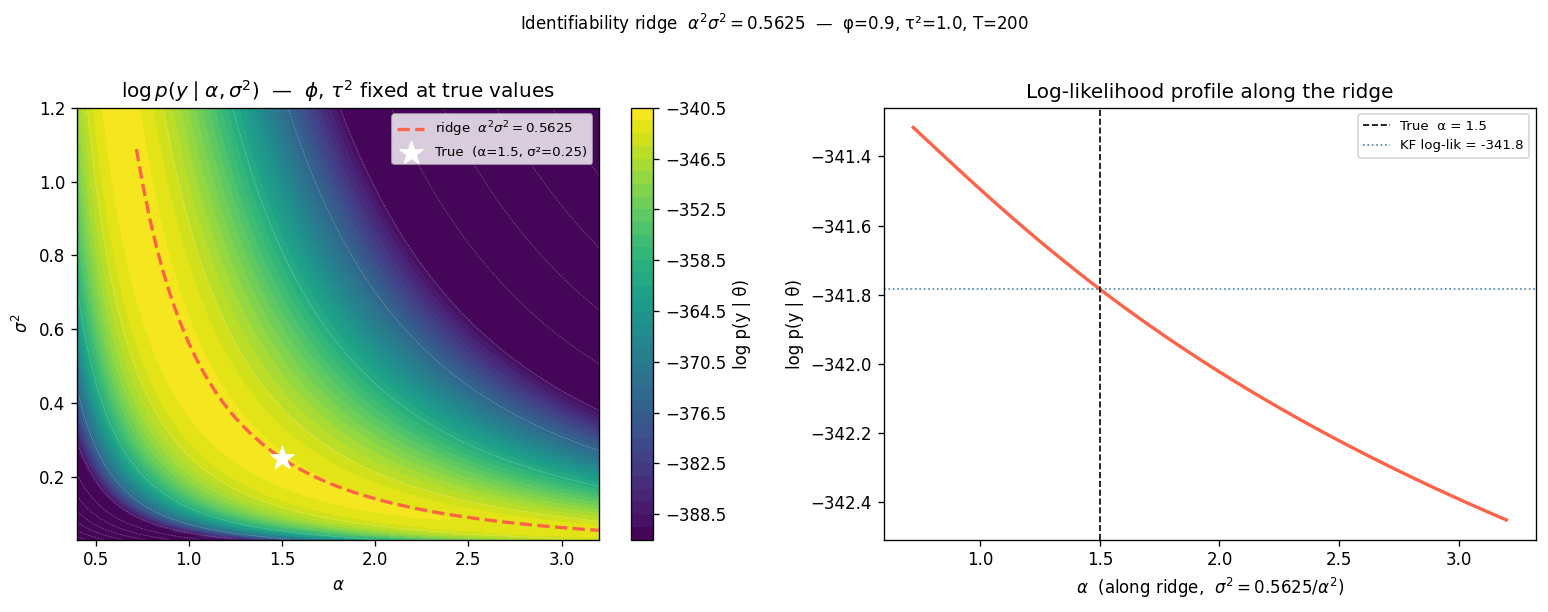

In [18]:
# Log-Likelihood Ridge Plot
# 2D slice of log p(y | alpha, sigma2) with phi and tau2 fixed at true values.
# The ridge lies along alpha^2 * sigma2 = alpha_true^2 * sigma2_true (scale ambiguity).

obs_1d = observations.ravel()

alpha_grid  = np.linspace(0.4, 3.2, 80)
sigma2_grid = np.linspace(0.03, 1.2, 80)

LL = np.full((len(sigma2_grid), len(alpha_grid)), np.nan)
for j, a in enumerate(alpha_grid):
    for i, s2 in enumerate(sigma2_grid):
        try:
            model.update_params([phi_true, a, s2, tau2_true])
            LL[i, j] = model.log_likelihood(obs_1d)
        except Exception:
            pass
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore

# Ridge curve: alpha^2 * sigma2 = C (scale-ambiguity constraint)
C_ridge      = alpha_true**2 * sigma2_true        # = 1.5^2 * 0.25 = 0.5625
ridge_sigma2 = C_ridge / alpha_grid**2
ridge_mask   = (ridge_sigma2 >= sigma2_grid.min()) & (ridge_sigma2 <= sigma2_grid.max())

# Log-likelihood evaluated exactly along the ridge
ridge_ll = []
for a in alpha_grid:
    s2 = C_ridge / a**2
    if s2 < sigma2_grid.min() or s2 > sigma2_grid.max():
        ridge_ll.append(np.nan)
        continue
    try:
        model.update_params([phi_true, a, s2, tau2_true])
        ridge_ll.append(model.log_likelihood(obs_1d))
    except Exception:
        ridge_ll.append(np.nan)
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore
ridge_ll = np.array(ridge_ll)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: filled contour heatmap ──────────────────────────────────────────
vmax = np.nanmax(LL)
vmin = vmax - 50
im = axes[0].contourf(alpha_grid, sigma2_grid, np.clip(LL, vmin, vmax),
                      levels=40, cmap='viridis')
axes[0].contour(alpha_grid, sigma2_grid, LL, levels=12,
                colors='white', linewidths=0.35, alpha=0.35)
fig.colorbar(im, ax=axes[0], label='log p(y | θ)')
axes[0].plot(alpha_grid[ridge_mask], ridge_sigma2[ridge_mask],
             '--', color='tomato', lw=2,
             label=r'ridge  $\alpha^2 \sigma^2 = %.4f$' % C_ridge)
axes[0].scatter([alpha_true], [sigma2_true],
                color='white', marker='*', s=200, zorder=5,
                label=f'True  (α={alpha_true}, σ²={sigma2_true})')
axes[0].set_xlabel(r'$\alpha$')
axes[0].set_ylabel(r'$\sigma^2$')
axes[0].set_title(r'$\log p(y \mid \alpha, \sigma^2)$  —  $\phi$, $\tau^2$ fixed at true values')
axes[0].legend(fontsize=8, loc='upper right')

# ── right: 1-D profile along the ridge ───────────────────────────────────
axes[1].plot(alpha_grid, ridge_ll, color='tomato', lw=2)
axes[1].axvline(alpha_true, ls='--', color='black', lw=1,
                label=f'True  α = {alpha_true}')
axes[1].axhline(kf_loglik, ls=':', color='steelblue', lw=1,
                label=f'KF log-lik = {kf_loglik:.1f}')
axes[1].set_xlabel(r'$\alpha$  (along ridge,  $\sigma^2 = {%.4f}/\alpha^2$)' % C_ridge)
axes[1].set_ylabel('log p(y | θ)')
axes[1].set_title('Log-likelihood profile along the ridge')
axes[1].legend(fontsize=8)

plt.suptitle(
    rf'Identifiability ridge  $\alpha^2 \sigma^2 = {C_ridge:.4f}$'
    rf'  —  φ={phi_true}, τ²={tau2_true}, T={T}',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()


### 2. Parameter Estimation with MLE

We fix $\alpha$ at its true value and maximise the exact Kalman log-likelihood over $(\phi, \sigma^2, \tau^2)$ using L-BFGS-B with multiple random restarts in unconstrained space. Standard errors are computed via the delta method: the numerical Hessian of the negative log-likelihood at the MLE is inverted, then propagated to the constrained space through the Jacobian of the reparameterisation.

In [19]:
# MLE with alpha fixed — 3-param model: (phi, sigma2, tau2)
# Uses the exact Kalman log-likelihood, so results are deterministic.

model_mle = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

mle = MLEEstimator(
    model=model_mle, # Calls model_mle.log_likelihood() which uses Kalman filter internally
    data=observations,
    method='L-BFGS-B',
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
mle_result = mle.fit()
mle.compute_std_errors()
print(mle_result.summary())


Restart 0/3 best val: 341.277620077348
Restart 1/3 best val: 341.277620077348
Restart 2/3 best val: 341.277620077348
MLEEstimator.fit  0.085s
MLEResult  loglik=-341.2776  converged  n_evals=64
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.885722      0.046616
  sigma2                0.250958      0.086108
  tau2                  0.865117      0.180643


### 3. Parameter Estimation with Metropolis-Hastings

We use a random-walk Metropolis-Hastings sampler in unconstrained space with weakly informative priors: Cauchy$(0,1)$ on $\phi$ (restricted to $(-1,1)$), HalfCauchy$(0,1)$ on $\sigma^2$ and $\tau^2$. Chain diagnostics include the trace, ACF, and ESS-adjusted posterior standard deviation, which inflates the raw posterior std by $\sqrt{n/\text{ESS}}$ to reflect autocorrelation.

In [20]:
# Fixing alpha breaks the alpha·sqrt(sigma2) ridge and makes the posterior
# identifiable.  Parameters are now (phi, sigma2, tau2) with variance params.

def log_prior_fixed_alpha(theta_con):
    """Independent priors on (phi, sigma2, tau2) with alpha fixed."""
    phi, sigma2, tau2 = theta_con
    if phi <= -1 or phi >= 1:
        return -np.inf
    if sigma2 <= 0 or tau2 <= 0:
        return -np.inf
    return sum([
        np.log(2) - np.log(1 + phi ** 2),     # Cauchy(0,1) on (-1,1) for phi
        -np.log(sigma2),                      # HalfCauchy(0,1) ∝ 1/sigma2
        -np.log(tau2),                        # HalfCauchy(0,1) ∝ 1/tau2
    ])


N_ITER_FA  = 3000
BURN_IN_FA = 500

model_fa  = FixedAlphaSSM(alpha_fixed = alpha_true, phi = phi_true, sigma2 = sigma2_true, tau2 = tau2_true, initial_var = initial_var_fixed, seed=5)
theta0_fa = model_fa.unconstrain_params(
    [phi_true, sigma2_true, tau2_true]
)

mh_fa = MetropolisHastings(
    model_fa, observations,
    n_iter=N_ITER_FA,
    step_sizes=np.array([0.06, 0.12, 0.12]),
    theta0=theta0_fa,
    log_prior=log_prior_fixed_alpha,
    seed=3,
)
print(mh_fa)


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=3000)


In [21]:
print("Running MH with fixed alpha=1.0 (3000 iterations) ...")
chain_fa, ll_fa, acc_fa = mh_fa.run()

constrained_fa = model_fa.constrain_chain(chain_fa[BURN_IN_FA:])

mh_fa.summary(burn=BURN_IN_FA)

names_fa   = list(model_fa.params_dict.keys())
true_fa    = [TRUE_PARAMS[p] for p in names_fa]


Running MH with fixed alpha=1.0 (3000 iterations) ...
MetropolisHastings.run  1.529s
param              mean        std
----------------------------------
phi              0.8738     0.0492
sigma2           0.2953     0.1011
tau2             0.8068     0.1813

Acceptance rate: 0.651  (burn=500)


In [22]:
cols = {
    "param": 8,
    "true": 10,
    "mean": 12,
    "std": 12,
    "adj": 16,
    "ess": 10,
}

header = (
    f"{'Param':<{cols['param']}}"
    f"{'True':>{cols['true']}}"
    f"{'Post mean':>{cols['mean']}}"
    f"{'Post std':>{cols['std']}}"
    f"{'Post std (adj)':>{cols['adj']}}"
    f"{'ESS':>{cols['ess']}}"
)

print("\n" + header)
print("─" * len(header))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    ess = chain_ess(samp)
    adj_std = samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan

    row = (
        f"{name:<{cols['param']}}"
        f"{true_fa[k]:>{cols['true']}.4f}"
        f"{samp.mean():>{cols['mean']}.4f}"
        f"{samp.std():>{cols['std']}.4f}"
        f"{adj_std:>{cols['adj']}.4f}"
        f"{ess:>{cols['ess']}.1f}"
    )
    print(row)


Param         True   Post mean    Post std  Post std (adj)       ESS
────────────────────────────────────────────────────────────────────
phi         0.9000      0.8738      0.0492          0.3892      39.9
sigma2      0.2500      0.2953      0.1011          0.8957      31.9
tau2        1.0000      0.8068      0.1813          1.3810      43.1


Post std (adj) are posterior standard deviation adjusted for effective sample size by dividing by sqrt(ESS).

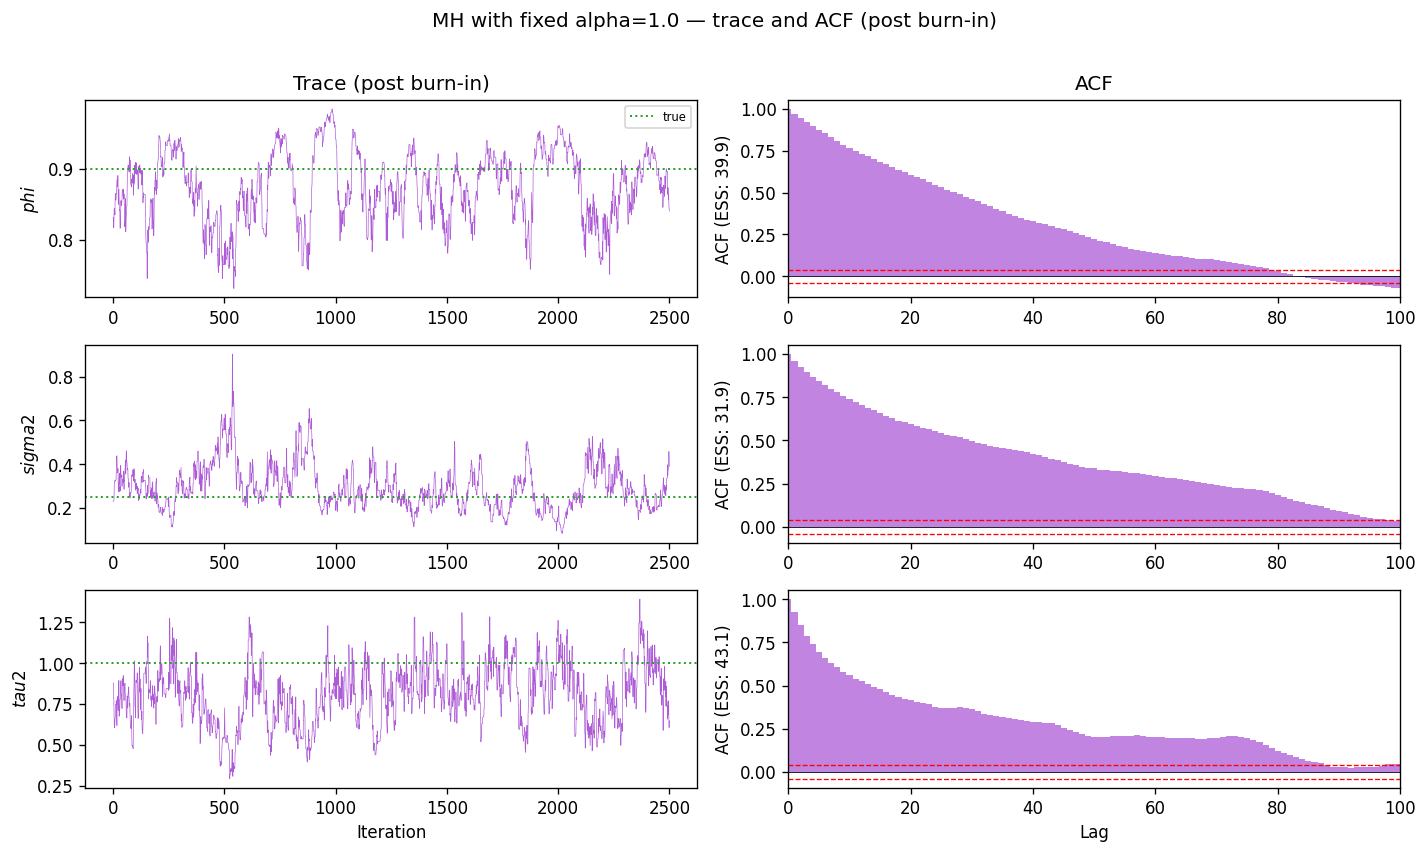

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='darkorchid', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    var     = xc.var()
    acf     = np.correlate(xc, xc, mode='full')[n_s - 1:] / (var * n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1],
             width=1.0, color='darkorchid', alpha=0.6)
    ax_a.axhline(0,  color='black', lw=0.5)
    ax_a.axhline( 1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.axhline(-1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.set_xlim(0, max_lag)
    ax_a.set_ylabel(f'ACF (ESS: {chain_ess(samp):.1f})') # Report ESS
    if k == 0:
        ax_a.set_title('ACF')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Lag')
plt.suptitle('MH with fixed alpha=1.0 — trace and ACF (post burn-in)', y=1.01)
plt.tight_layout()
plt.show()


### 4. Parameter Estimation with Nelder-Mead PMMLE

As an alternative to the exact likelihood, we optimise the particle-filter log-likelihood estimate using a derivative-free two-stage Nelder-Mead algorithm. Stage 1 performs a coarse global search with $N_1$ particles and multiple random restarts; stage 2 refines from the best stage-1 result using $N_2 > N_1$ particles and tighter tolerances. Within each stage the PF seed is fixed, making the objective deterministic.

In [24]:
# Nelder-Mead PMMLE with alpha fixed — same 3-param model.
# Uses particle-filter log-likelihood estimate; expect ~3 min runtime.

from estimation.nelder_mead import NelderMeadPMMLE

model_nm = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

nm = NelderMeadPMMLE(
    model=model_nm,
    data=observations,
    N_particles_1=100,
    N_particles_2=300,
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
nm_result = nm.fit()
print(nm_result.summary())


Stage 1  N_particles=100, 3 restart(s)
  restart 1/3: loglik≈-340.16  nfev=125  converged
  restart 2/3: loglik≈-345.42  nfev=139  converged
  restart 3/3: loglik≈-341.15  nfev=154  converged

Stage 2  N_particles=300, starting from stage-1 best
  loglik≈-341.27  nfev=152  converged
NelderMeadPMMLE.fit  117.169s
PMMResult  loglik=-342.0694
  Stage 1: converged  n_evals=418
  Stage 2: converged  n_evals=152
  Optimization terminated successfully.

  Parameter             Estimate
  --------------------------------
  phi                   0.905936
  sigma2                0.228670
  tau2                  1.000096


### 5. Parameter Estimation with Hamiltonian Monte Carlo

HMC exploits the analytic score (gradient of the Kalman log-likelihood, implemented in `SimpleLinearGaussianSSM.score`) to propose distant moves in parameter space with high acceptance probability. The leapfrog integrator uses the exact score for the likelihood term and central finite differences for the prior and log-Jacobian correction. `FixedAlphaSSM.score` strips the $\alpha$ component from the full score before passing it to HMC.

HamiltonianMC(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=3000, step_size=0.04, n_leapfrog=15)
Running HMC ...
HamiltonianMC.run  126.164s
param              mean        std
----------------------------------
phi              0.8655     0.0592
sigma2           0.3038     0.1198
tau2             0.8123     0.2194

Acceptance rate: 0.991  (burn=500)


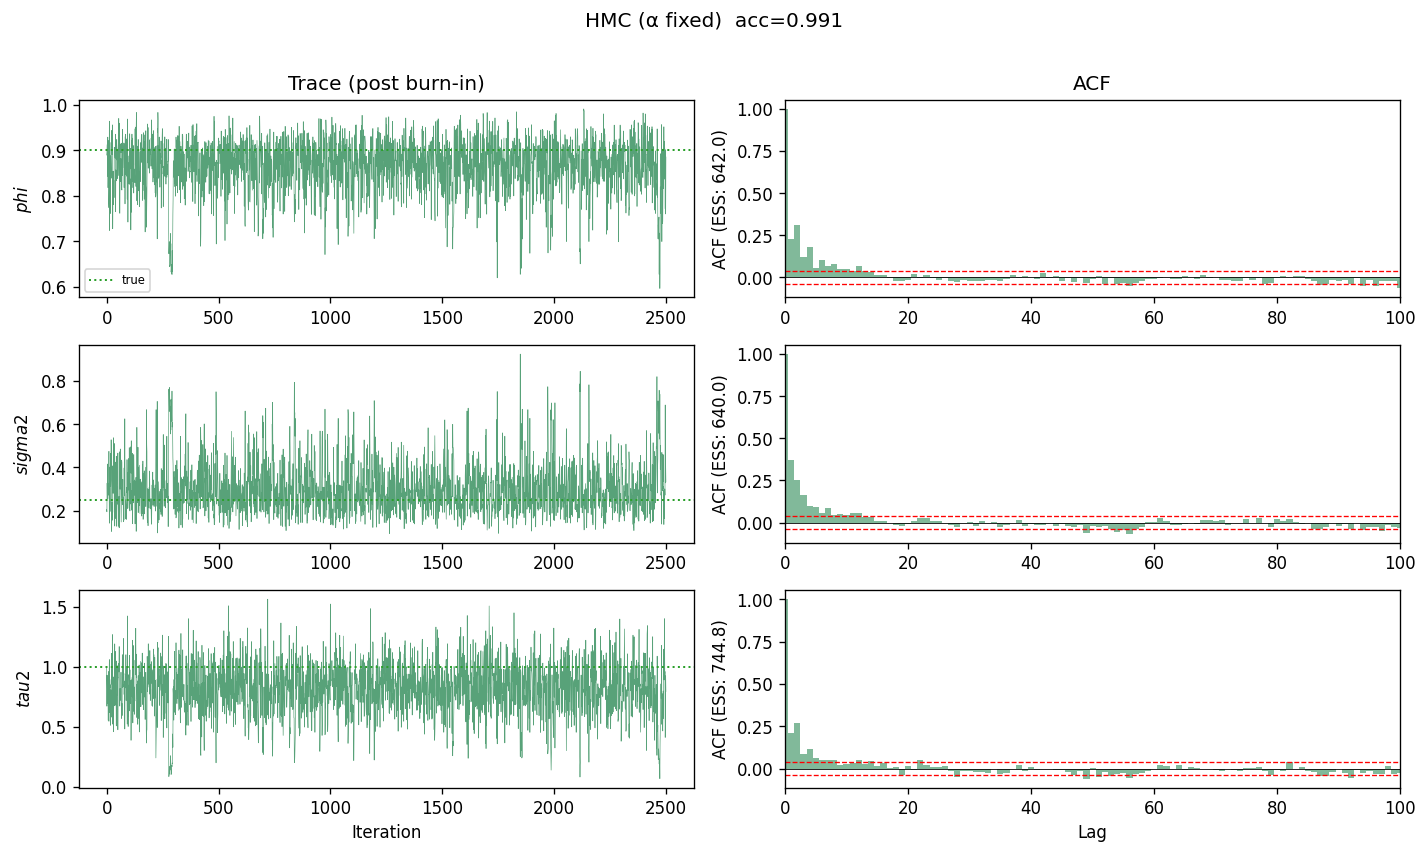

In [25]:
from estimation.hamilton_mc import HamiltonianMC

N_ITER_HMC  = 3000
BURN_IN_HMC = 500

model_hmc = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

theta0_hmc = model_hmc.unconstrain_params([phi_true, sigma2_true, tau2_true])

def log_prior_hmc(theta_con):
    phi, sigma2, tau2 = theta_con
    if abs(phi) >= 1 or sigma2 <= 0 or tau2 <= 0:
        return -np.inf
    return (np.log(2) - np.log(1 + phi**2)
            - np.log(sigma2) - np.log(tau2))

hmc = HamiltonianMC(
    model=model_hmc, data=observations,
    n_iter=N_ITER_HMC, step_size=0.04, n_leapfrog=15,
    theta0=theta0_hmc, log_prior=log_prior_hmc, seed=7,
)
print(hmc)
print("Running HMC ...")
chain_hmc, ll_hmc, acc_hmc = hmc.run()

constrained_hmc = model_hmc.constrain_chain(chain_hmc[BURN_IN_HMC:])
names_hmc       = list(model_hmc.params_dict.keys())
hmc.summary(burn=BURN_IN_HMC)

fig, axes = plt.subplots(3, 2, figsize=(12, 7))
for k, name in enumerate(names_hmc):
    samp = constrained_hmc[:, k]
    tv   = TRUE_PARAMS[name]
    axes[k, 0].plot(samp, lw=0.4, color='seagreen', alpha=0.8)
    axes[k, 0].axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    axes[k, 0].set_ylabel(f'${name}$')
    if k == 0:
        axes[k, 0].set_title('Trace (post burn-in)'); axes[k, 0].legend(fontsize=7)
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    acf     = np.correlate(xc, xc, mode='full')[n_s-1:] / (xc.var() * n_s)
    axes[k, 1].bar(np.arange(max_lag+1), acf[:max_lag+1], width=1.0, color='seagreen', alpha=0.6)
    axes[k, 1].axhline(0, color='black', lw=0.5)
    axes[k, 1].axhline( 1.96/np.sqrt(n_s), color='red', ls='--', lw=0.8)
    axes[k, 1].axhline(-1.96/np.sqrt(n_s), color='red', ls='--', lw=0.8)
    axes[k, 1].set_xlim(0, max_lag)
    axes[k, 1].set_ylabel(f'ACF (ESS: {chain_ess(samp):.1f})')
    if k == 0:
        axes[k, 1].set_title('ACF')
axes[-1, 0].set_xlabel('Iteration'); axes[-1, 1].set_xlabel('Lag')
plt.suptitle(f'HMC (α fixed)  acc={acc_hmc.mean():.3f}', y=1.01)
plt.tight_layout(); plt.show()


### 6. Comparison Summary

All four estimators target the same posterior / likelihood under the same fixed-$\alpha$ model. We compare point estimates, uncertainty measures, and log-likelihoods side by side. MLE reports delta-method standard errors; MH and HMC report ESS-adjusted posterior standard deviations; the Nelder-Mead PMMLE is a point estimate with no uncertainty quantification.

In [26]:
# Comparison: True | MLE | MH | NM PMMLE
# MLE SE:        delta-method standard errors in constrained space
# MH std (adj):  posterior std scaled by sqrt(n/ESS) to reflect MCMC autocorrelation

names_est = list(model_mle.params_dict.keys())   # ['phi', 'sigma2', 'tau2']
mle_con   = list(mle_result.constrained_params)
nm_con    = list(nm_result.constrained_params)

# MH posterior summaries (post-burn-in)
mh_mean, mh_adj_std = [], []
for k in range(len(names_est)):
    samp = constrained_fa[:, k]
    ess  = chain_ess(samp)
    mh_mean.append(samp.mean())
    mh_adj_std.append(samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan)

# ── print table ───────────────────────────────────────────────────────────────
w = [10, 8, 10, 9, 10, 12, 10]
header = (
    f"{'Param':<{w[0]}} {'True':>{w[1]}} {'MLE':>{w[2]}} {'MLE SE':>{w[3]}}"
    f" {'MH mean':>{w[4]}} {'MH std(adj)':>{w[5]}} {'NM PMMLE':>{w[6]}}"
)
print(header)
print("─" * len(header))

for k, name in enumerate(names_est):
    tv = TRUE_PARAMS[name]
    se = (f"{mle_result.std_errors[k]:>{w[3]}.4f}"
          if mle_result.std_errors is not None and not np.isnan(mle_result.std_errors[k])
          else f"{'—':>{w[3]}}")
    print(
        f"{name:<{w[0]}} {tv:>{w[1]}.4f} {mle_con[k]:>{w[2]}.4f} {se}"
        f" {mh_mean[k]:>{w[4]}.4f} {mh_adj_std[k]:>{w[5]}.4f} {nm_con[k]:>{w[6]}.4f}"
    )

print()
print(f"{'Log-likelihood':<22} {'KF (exact)':>12} {'MLE':>12} {'—':>12} {'NM PMMLE (PF)':>14}")
print("─" * 64)
print(f"{'':22} {kf_loglik:>12.2f} {mle_result.loglik:>12.2f} {'—':>12} {nm_result.loglik:>14.2f}")

Param          True        MLE    MLE SE    MH mean  MH std(adj)   NM PMMLE
───────────────────────────────────────────────────────────────────────────
phi          0.9000     0.8857    0.0466     0.8738       0.3892     0.9059
sigma2       0.2500     0.2510    0.0861     0.2953       0.8957     0.2287
tau2         1.0000     0.8651    0.1806     0.8068       1.3810     1.0001

Log-likelihood           KF (exact)          MLE            —  NM PMMLE (PF)
────────────────────────────────────────────────────────────────
                            -341.78      -341.28            —        -342.07


## Section IV: Estimation Extension — MCMC Diagnostics

This section investigates three practical aspects of MH estimation that go beyond the basic results in Section III: how many iterations are needed, what happens when $\alpha$ is misspecified, and how to use the posterior for formal inference.

1. Convergence of posterior mean as a function of chain length
2. Effect of misspecified fixed $\alpha$ on MLE and parameter estimates
3. Posterior credible intervals and a likelihood ratio test for $\alpha$

### 1. Convergence vs. Chain Length

MetropolisHastings.run  0.104s
MetropolisHastings.run  0.291s
MetropolisHastings.run  0.510s
MetropolisHastings.run  1.034s
MetropolisHastings.run  1.434s


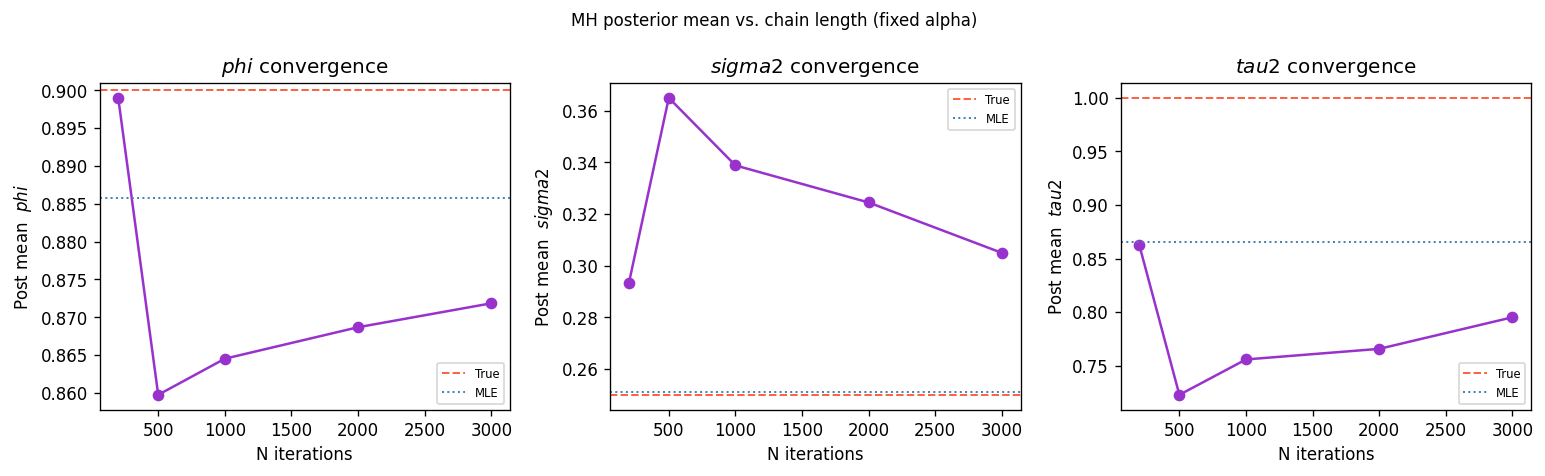

In [27]:
### 1. Effect of Number of Iterations — Convergence of MH

n_iter_vals = [200, 500, 1000, 2000, 3000]
running_means = {name: [] for name in names_fa}

for n_it in n_iter_vals:
    mh_conv = MetropolisHastings(
        model_fa, observations,
        n_iter=n_it, step_sizes=np.array([0.06, 0.12, 0.12]),
        theta0=theta0_fa, log_prior=log_prior_fixed_alpha, seed=3,
    )
    ch, _, _ = mh_conv.run()
    burn = min(100, n_it // 4)
    con  = model_fa.constrain_chain(ch[burn:])
    for k, name in enumerate(names_fa):
        running_means[name].append(con[:, k].mean())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for k, (ax, name) in enumerate(zip(axes, names_fa)):
    ax.plot(n_iter_vals, running_means[name], 'o-', color='darkorchid', lw=1.5)
    ax.axhline(TRUE_PARAMS[name], color='tomato', ls='--', lw=1.2, label='True')
    ax.axhline(mle_result.constrained_params[k], color='steelblue', ls=':', lw=1.2, label='MLE')
    ax.set_xlabel('N iterations'); ax.set_ylabel(f'Post mean  ${name}$')
    ax.set_title(f'${name}$ convergence'); ax.legend(fontsize=7)
plt.suptitle('MH posterior mean vs. chain length (fixed alpha)', fontsize=10)
plt.tight_layout(); plt.show()


### 2. Effect of Misspecified Fixed Alpha

Restart 0/1 best val: 340.6500815792328
MLEEstimator.fit  0.031s
Restart 0/1 best val: 340.9816455201653
MLEEstimator.fit  0.024s
Restart 0/1 best val: 341.277620077348
MLEEstimator.fit  0.032s
Restart 0/1 best val: 341.5204862499895
MLEEstimator.fit  0.021s
Restart 0/1 best val: 341.72143626836964
MLEEstimator.fit  0.026s
 alpha_fixed     loglik    phi_MLE   sigma2_MLE   tau2_MLE
──────────────────────────────────────────────────────────
        0.50    -340.65     0.8860       2.2572     0.8618
        1.00    -340.98     0.8858       0.5645     0.8641
        1.50    -341.28     0.8857       0.2510     0.8651 ← true
        2.00    -341.52     0.8857       0.1412     0.8656
        2.50    -341.72     0.8856       0.0904     0.8659


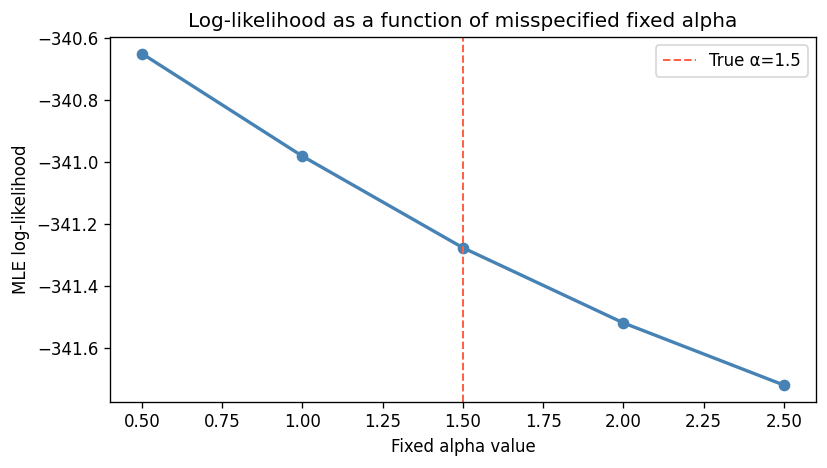

In [28]:
### 2. Effect of Misspecified Fixed Alpha

alpha_values = [0.5, 1.0, alpha_true, 2.0, 2.5]   # alpha_true = 1.5
colors_ms = plt.cm.plasma(np.linspace(0.1, 0.9, len(alpha_values)))

results_ms = {}
for a_fixed in alpha_values:
    m_ms = FixedAlphaSSM(alpha_fixed=a_fixed, phi=phi_true, sigma2=sigma2_true,
                          tau2=tau2_true, initial_var=initial_var_fixed, seed=5)
    th0  = m_ms.unconstrain_params([phi_true, sigma2_true, tau2_true])
    mle_ms = MLEEstimator(model=m_ms, data=observations, method='L-BFGS-B',
                           n_restarts=1, seed=0)
    res = mle_ms.fit(theta0=th0)
    results_ms[a_fixed] = res

# Report
print(f"{'alpha_fixed':>12} {'loglik':>10} {'phi_MLE':>10} {'sigma2_MLE':>12} {'tau2_MLE':>10}")
print("─" * 58)
for a, res in results_ms.items():
    cp = list(res.constrained_params)
    marker = " ← true" if abs(a - alpha_true) < 0.01 else ""
    print(f"{a:>12.2f} {res.loglik:>10.2f} {cp[0]:>10.4f} {cp[1]:>12.4f} {cp[2]:>10.4f}{marker}")

# Plot log-likelihood vs alpha_fixed
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_values, [results_ms[a].loglik for a in alpha_values], 'o-', color='steelblue', lw=2)
ax.axvline(alpha_true, color='tomato', ls='--', lw=1.2, label=f'True α={alpha_true}')
ax.set_xlabel('Fixed alpha value'); ax.set_ylabel('MLE log-likelihood')
ax.set_title('Log-likelihood as a function of misspecified fixed alpha')
ax.legend(); plt.tight_layout(); plt.show()


### 3. Hypothesis Testing on Estimated Parameters

In [29]:
### 3. Hypothesis Testing on Estimated Parameters

# 95% posterior credible intervals from MH chain (post burn-in)
print(f"\n95% Posterior Credible Intervals (MH, alpha fixed = {alpha_true})")
print(f"{'Param':<10} {'True':>8} {'Post mean':>10} {'2.5%':>8} {'97.5%':>8} {'In CI':>7}")
print("─" * 56)
for k, name in enumerate(names_fa):
    samp  = constrained_fa[:, k]
    lo, hi = np.percentile(samp, [2.5, 97.5])
    tv    = TRUE_PARAMS[name]
    in_ci = '✓' if lo <= tv <= hi else '✗'
    print(f"{name:<10} {tv:>8.4f} {samp.mean():>10.4f} {lo:>8.4f} {hi:>8.4f} {in_ci:>7}")

# Likelihood ratio test: compare MLE with alpha free vs alpha fixed
# Model A: alpha fixed (3 params), Model B: full model (4 params)
# LRT statistic: 2*(ll_B - ll_A) ~ chi^2(1) under H0: alpha = alpha_true
model_full = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma2=sigma2_true,
                                      tau2=tau2_true, initial_var=initial_var_fixed, seed=SEED)
mle_full = MLEEstimator(model=model_full, data=observations, method='L-BFGS-B',
                         n_restarts=2, seed=0)
res_full = mle_full.fit()

from scipy.stats import chi2
lrt_stat = 2.0 * (res_full.loglik - mle_result.loglik)
p_val    = chi2.sf(lrt_stat, df=1)   # 1 df: alpha freed

print(f"\nLikelihood Ratio Test: H₀ alpha = {alpha_true} (fixed) vs H₁ alpha free")
print(f"  LL (alpha fixed) : {mle_result.loglik:.4f}")
print(f"  LL (alpha free)  : {res_full.loglik:.4f}")
print(f"  LRT statistic    : {lrt_stat:.4f}")
print(f"  p-value (chi²(1)): {p_val:.4f}  {'→ fail to reject H₀' if p_val > 0.05 else '→ reject H₀'}")



95% Posterior Credible Intervals (MH, alpha fixed = 1.5)
Param          True  Post mean     2.5%    97.5%   In CI
────────────────────────────────────────────────────────
phi          0.9000     0.8738   0.7730   0.9583       ✓
sigma2       0.2500     0.2953   0.1369   0.5562       ✓
tau2         1.0000     0.8068   0.4707   1.1617       ✓
Restart 0/2 best val: 340.4616714404975
Restart 1/2 best val: 340.46164440210777
MLEEstimator.fit  1.894s

Likelihood Ratio Test: H₀ alpha = 1.5 (fixed) vs H₁ alpha free
  LL (alpha fixed) : -341.2776
  LL (alpha free)  : -340.4616
  LRT statistic    : 1.6320
  p-value (chi²(1)): 0.2014  → fail to reject H₀


## Section V: Estimation Extension — PMMH and Blocked PMMH

Particle Marginal Metropolis-Hastings (PMMH) replaces the intractable marginal likelihood with an unbiased PF estimate, yielding an exact Markov chain for the posterior despite the approximation. We compare the vanilla single-block PMMH — which proposes all parameters jointly — against a blocked variant that proposes the dynamics parameter (φ) and the noise variances (σ², τ²) in separate blocks. Blocking typically reduces autocorrelation and improves ESS per iteration.

In [30]:
# ── setup: naive PMMH and Block PMMH, both with alpha fixed ──────────────────
# Block structure: dynamics (phi=0) and noise variances (sigma2=1, tau2=2).
BLOCKS      = [[0], [1, 2]]   # dynamics block, noise variance block
N_ITER_CMP  = 2000
N_PART_CMP  = 200
BURN_IN_CMP = 500

model_n = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=1)
model_b = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=2)

theta0_cmp = model_n.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)
step_cmp = np.array([0.10, 0.15, 0.15])   # per-dim steps: (atanh φ, log σ², log τ²)

pf_n   = ParticleFilter(model_n, N_PART_CMP, observations, SystematicResampling(seed=1))
pmmh_n = PMMH(model_n, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step_cmp, theta0=theta0_cmp,
              log_prior=log_prior_fixed_alpha, seed=10)

pf_b   = ParticleFilter(model_b, N_PART_CMP, observations, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model_b, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step_cmp, theta0=theta0_cmp,
                   log_prior=log_prior_fixed_alpha,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))

PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=200)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=200, n_blocks=2)


In [31]:
print("Running naive PMMH (alpha fixed=1.0) ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

Running naive PMMH (alpha fixed=1.0) ...
[500/2000]  theta = [ 0.33983774 -0.3223777  -0.05916066],  loglik = -340.89,  accept rate = 0.298
[1000/2000]  theta = [ 0.68577583 -0.66027147 -0.11055464],  loglik = -343.51,  accept rate = 0.294
[1500/2000]  theta = [ 1.04760099 -1.00693902 -0.14331983],  loglik = -341.31,  accept rate = 0.300
PMMH.run  538.285s
  acceptance rate: 0.299


In [32]:
print("Running Block PMMH (alpha fixed=1.0) ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

Running Block PMMH (alpha fixed=1.0) ...
BlockPMMH.run  1073.296s
  acceptance rate: 0.552


In [33]:
constrained_n = model_n.constrain_chain(chain_n[BURN_IN_CMP:])
constrained_b = model_b.constrain_chain(chain_b[BURN_IN_CMP:])

In [34]:
names_cmp = list(model_n.params_dict.keys())
print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12} {'Naive ESS':>8} {'Block mean':>12} {'Block ESS':>8}")
print("─" * 46)
for k, name in enumerate(names_cmp):
    naive_ess = chain_ess(constrained_n[:, k])
    block_ess = chain_ess(constrained_b[:,k])
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{naive_ess:>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}  "
          f"{block_ess:>12.4f}")


              True    Naive mean Naive ESS   Block mean Block ESS
──────────────────────────────────────────────
phi         0.9000        0.8696       22.5065        0.8690       11.1366
sigma2      0.2500        0.2965       13.5071        0.2770       13.2081
tau2        1.0000        0.8213       16.0414        0.8476       17.5221


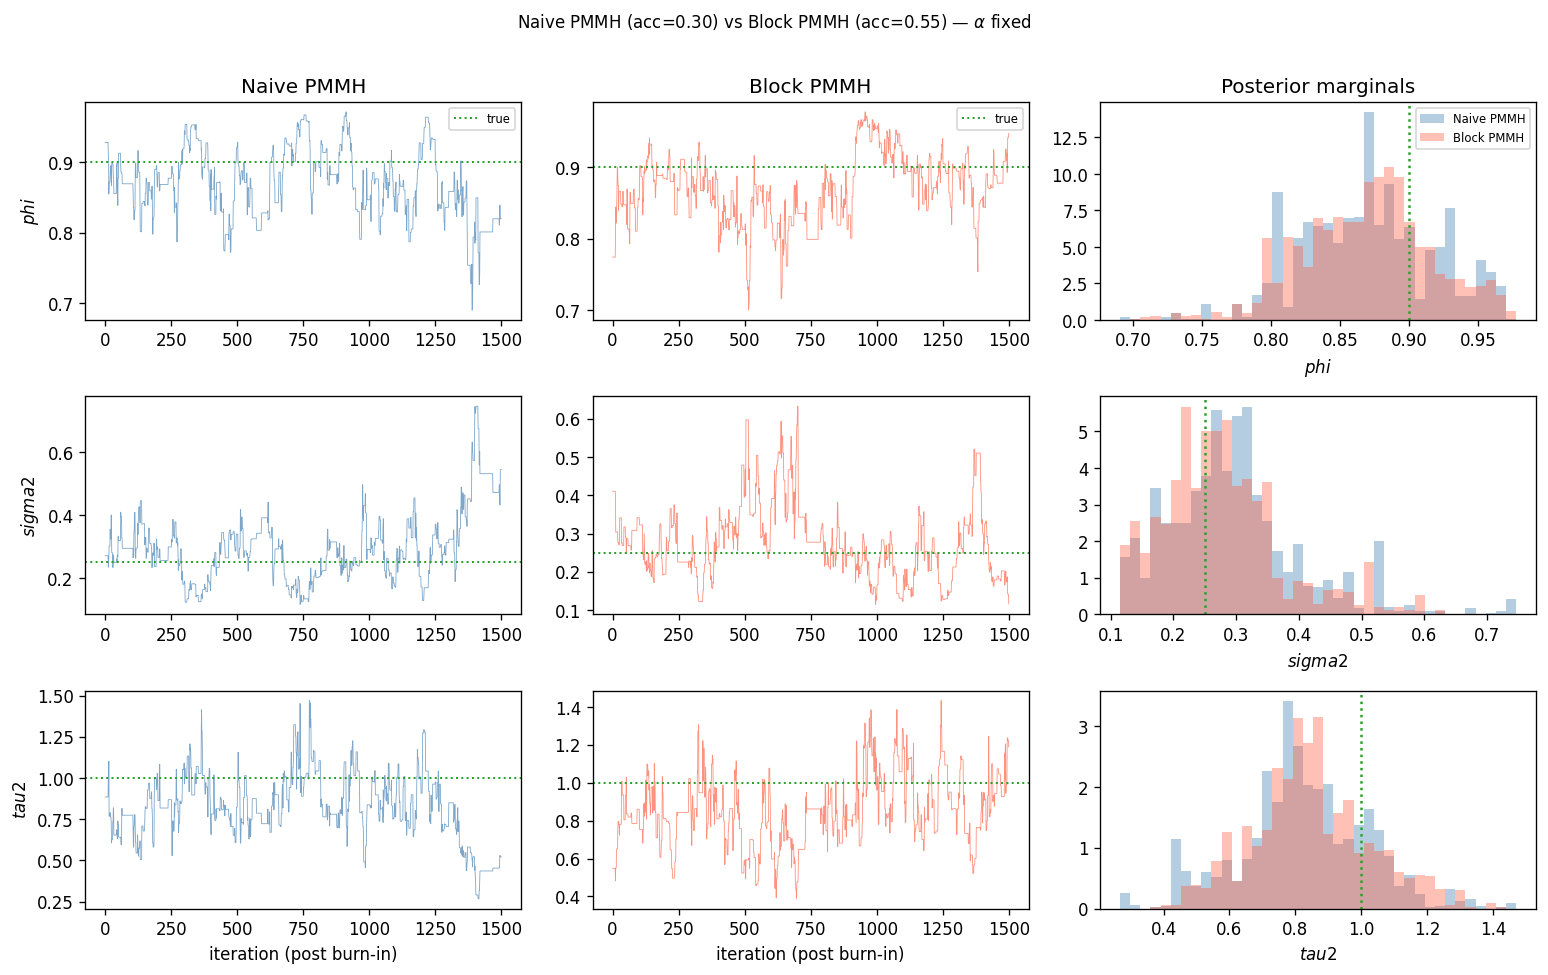

In [35]:
# ── trace plots and posterior comparison ──────────────────────────────────────
names_cmp = list(model_n.params_dict.keys())
fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for k, name in enumerate(names_cmp):
    tv = TRUE_PARAMS[name]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})'
    r' — $\alpha$ fixed',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


## Section VI: Regime-Switching Model — Synthetic Data and RBPF Filtering

We introduce a two-regime Markov-switching linear Gaussian SSM where only the process noise variance is regime-dependent (low-volatility expansion vs. high-volatility recession). The Rao-Blackwellised particle filter (RBPF) marginalises the continuous latent state $x_t$ analytically for each discrete regime particle via a per-particle Kalman filter, yielding substantially more accurate regime detection than a bootstrap PF at the same N.

1. Model setup, true parameters, and synthetic data generation
2. RBPF filtering under true parameters — filtered state, regime probabilities, RMSE

SimpleRegimeSwitchingSSM
  1-D regime-switching linear Gaussian SSM
  Regimes: 2  (sigma2 is regime-specific; phi, alpha, tau2 shared)
  Transition:  x_t = 0.9 * x_{t-1} + eps_t,  eps_t ~ N(0, sigma2_{s_t})
  Observation: y_t = 1.0 * x_t + nu_t,  nu_t ~ N(0, 1.0)
  sigma2 per regime: [0.3, 1.5]
  Stationary var per regime: [1.5789, 7.8947]
  Stationary regime probs: [0.6, 0.4]
  Regime transition matrix:
[[0.9  0.1 ]
 [0.15 0.85]]

Regime counts:  Low-vol=118 (59%)  High-vol=82 (41%)


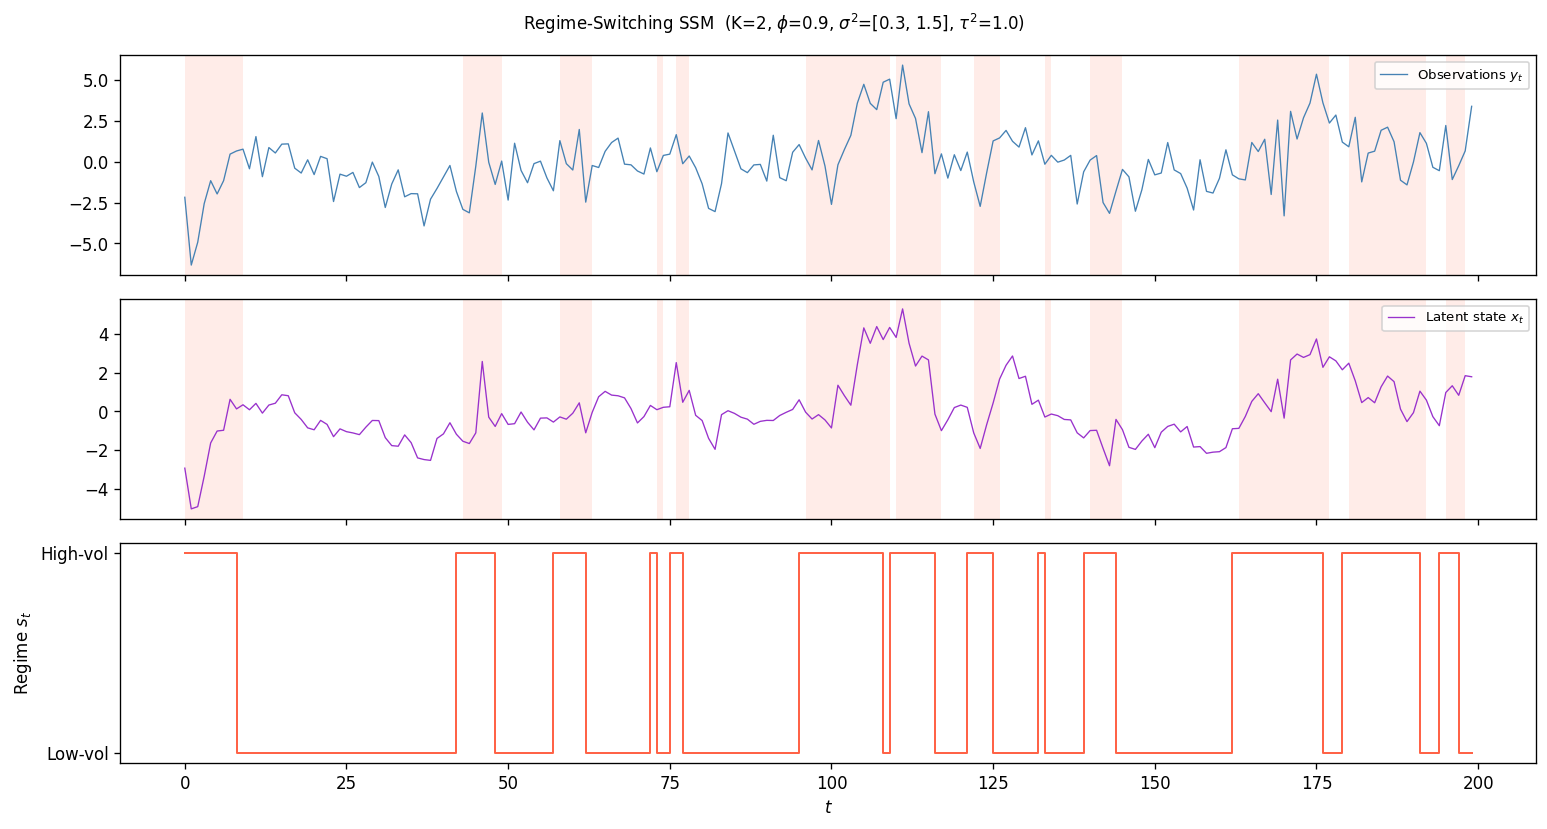

In [43]:
# ── True parameters ──────────────────────────────────────────────────────────
K_RS    = 2
T_RS    = 200
SEED_RS = 42

phi_rs    = 0.90
alpha_rs  = 1.0                          # fixed for identifiability
sigma2_rs = np.array([0.30, 1.50])       # regime 0: quiet, regime 1: turbulent
tau2_rs   = 1.0
P_rs      = np.array([[0.90, 0.10],
                       [0.15, 0.85]])    # ~90% / ~85% within-regime persistence

TRUE_RS = {'phi': phi_rs, 'sigma2_0': sigma2_rs[0], 'sigma2_1': sigma2_rs[1], 'tau2': tau2_rs, 'P_00': P_rs[0, 0], 'P_11': P_rs[1, 1], 'P_01': P_rs[0, 1], 'P_10': P_rs[1, 0]}

rs_model = SimpleRegimeSwitchingSSM(
    phi=phi_rs, alpha=alpha_rs,
    sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=SEED_RS,
)
print(rs_model.describe())

# ── Generate synthetic data ───────────────────────────────────────────────────
rs_states, rs_regimes, rs_obs = rs_model.generate_data(T_RS)

counts = np.bincount(rs_regimes, minlength=K_RS)
print(f"\nRegime counts:  Low-vol={counts[0]} ({100*counts[0]/T_RS:.0f}%)  "
      f"High-vol={counts[1]} ({100*counts[1]/T_RS:.0f}%)")

# ── Plot ──────────────────────────────────────────────────────────────────────
def regime_spans(regimes, target=1):
    spans, in_span = [], False
    for t, r in enumerate(regimes):
        if r == target and not in_span:
            start, in_span = t, True
        elif r != target and in_span:
            spans.append((start, t)); in_span = False
    if in_span:
        spans.append((start, len(regimes)))
    return spans

t_rs         = np.arange(T_RS)
high_vol_spans = regime_spans(rs_regimes, target=1)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_rs, rs_obs[:, 0],    lw=0.8, color='steelblue',  label='Observations $y_t$')
axes[1].plot(t_rs, rs_states[:, 0], lw=0.8, color='darkorchid', label='Latent state $x_t$')
axes[2].step(t_rs, rs_regimes, lw=1.2, color='tomato')
axes[2].set_yticks([0, 1]);  axes[2].set_yticklabels(['Low-vol', 'High-vol'])
axes[2].set_ylabel('Regime $s_t$')

for ax in axes[:2]:
    for s, e in high_vol_spans:
        ax.axvspan(s, e, alpha=0.12, color='tomato', lw=0)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('$t$')
fig.suptitle(
    rf'Regime-Switching SSM  (K={K_RS}, $\phi$={phi_rs}, '
    rf'$\sigma^2$={sigma2_rs.tolist()}, $\tau^2$={tau2_rs})',
    fontsize=10,
)
plt.tight_layout()
plt.show()


RBPF log-likelihood: -363.62
RBPF RMSE (vs true state): 0.6444


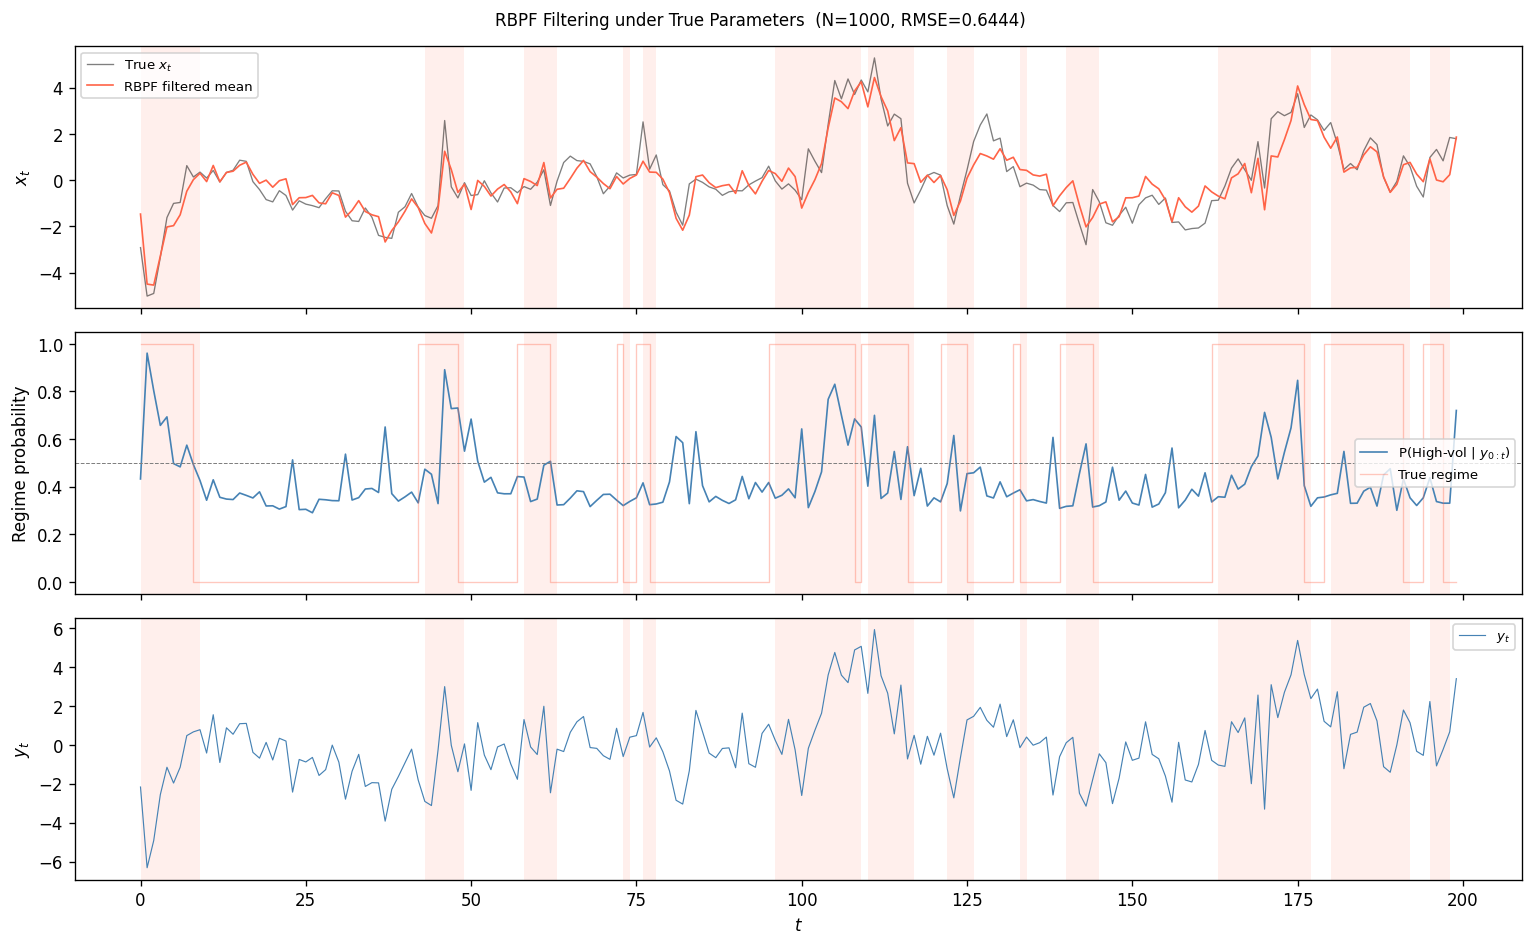

In [37]:
# ── Run RBPF ─────────────────────────────────────────────────────────────────
N_RBPF = 1000

rbpf = RaoBlackwellizedParticleFilter(
    model=rs_model,
    N_particles=N_RBPF,
    data=rs_obs,
    resample_method=SystematicResampling(seed=SEED_RS),
)
rbpf_states, _, _, _, rbpf_loglik = rbpf.run_filter()
rbpf_states       = rbpf_states[:, 0]
rbpf_regime_probs = rbpf.regime_prob_history   # (T, K)

rbpf_rmse = rmse(rs_states[:, 0], rbpf_states)
print(f"RBPF log-likelihood: {rbpf_loglik:.2f}")
print(f"RBPF RMSE (vs true state): {rbpf_rmse:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t_rs, rs_states[:, 0], lw=0.8, color='black', alpha=0.5, label='True $x_t$')
axes[0].plot(t_rs, rbpf_states,     lw=1.0, color='tomato',            label='RBPF filtered mean')
axes[0].set_ylabel('$x_t$');  axes[0].legend(fontsize=8)

axes[1].plot(t_rs, rbpf_regime_probs[:, 1], lw=1.0, color='steelblue',
             label='P(High-vol | $y_{0:t}$)')
axes[1].step(t_rs, rs_regimes, lw=0.8, color='tomato', alpha=0.35, label='True regime')
axes[1].axhline(0.5, color='grey', lw=0.6, ls='--')
axes[1].set_ylim(-0.05, 1.05);  axes[1].set_ylabel('Regime probability')
axes[1].legend(fontsize=8)

axes[2].plot(t_rs, rs_obs[:, 0], lw=0.7, color='steelblue', label='$y_t$')
axes[2].set_ylabel('$y_t$');  axes[2].legend(fontsize=8)

for ax in axes:
    for s, e in high_vol_spans:
        ax.axvspan(s, e, alpha=0.10, color='tomato', lw=0)

axes[-1].set_xlabel('$t$')
fig.suptitle(f'RBPF Filtering under True Parameters  (N={N_RBPF}, RMSE={rbpf_rmse:.4f})',
             fontsize=10)
plt.tight_layout()
plt.show()


## Section VII: Regime-Switching Model — Parameter Estimation

With the RBPF providing an efficient marginal likelihood estimator we apply two estimation methods to the regime-switching model. $\alpha$ is fixed to remove the scale ambiguity. The estimated parameters are $(\phi, \sigma^2_0, \sigma^2_1, \tau^2, P)$ where $P$ is the $2\times 2$ Markov transition matrix.

1. Nelder-Mead RBPF-PMLE: two-stage derivative-free optimisation of the RBPF log-likelihood
2. RBPF-PMMH: full Bayesian inference via PMMH with the RBPF as the likelihood estimator

In [46]:
# ── Model for estimation (alpha fixed, estimates phi, sigma2_0, sigma2_1, tau2, P) ──
model_nm_rs = FixedAlphaRS(
    alpha_fixed=alpha_rs,
    phi=phi_rs, sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=SEED_RS,
)

# ── Two-stage Nelder-Mead RBPF-PMLE ──────────────────────────────────────────
# Stage 1: coarse search with fewer particles (N=150, 3 restarts)
# Stage 2: refinement with more particles (N=500) from the stage-1 best
nm_rs = NelderMeadPMMLE(
    model=model_nm_rs,
    data=rs_obs,
    N_particles_1=100,
    N_particles_2=1000,
    filter_cls=RaoBlackwellizedParticleFilter,
    n_restarts=3,
    restart_std=0.4,
    seed=0,
)
print(nm_rs)

nm_rs_result = nm_rs.fit()
print()
print(nm_rs_result.summary())


NelderMeadPMMLE(model=FixedAlphaRS(n_regimes=2, alpha_fixed=1.0, phi=0.9, sigma2=[0.3, 1.5], tau2=1.0), N1=100, N2=1000, n_restarts=3)
Stage 1  N_particles=100, 3 restart(s)
  restart 1/3: loglik≈-362.81  nfev=438  converged
  restart 2/3: loglik≈-360.97  nfev=378  converged
  restart 3/3: loglik≈-362.54  nfev=2094  converged

Stage 2  N_particles=1000, starting from stage-1 best
  loglik≈-361.34  nfev=562  converged
NelderMeadPMMLE.fit  148.941s

PMMResult  loglik=-362.8860
  Stage 1: converged  n_evals=2910
  Stage 2: converged  n_evals=562
  Optimization terminated successfully.

  Parameter             Estimate
  --------------------------------
  phi                   0.849856
  sigma2_0              0.273320
  sigma2_1              1.935795
  tau2                  1.043023
  P_00                  0.871213
  P_01                  0.128787
  P_10                  0.159546
  P_11                  0.840454


In [47]:
# ── Comparison table: True vs RBPF-PMLE ──────────────────────────────────────
names_nm_rs = list(model_nm_rs.params_dict.keys())
nm_rs_con   = list(nm_rs_result.constrained_params)

print(f"\n{'Param':<12} {'True':>10} {'RBPF-PMLE':>12}")
print("─" * 38)
for k, name in enumerate(names_nm_rs):
    tv = TRUE_RS.get(name, float('nan'))
    print(f"{name:<12} {tv:>10.4f} {nm_rs_con[k]:>12.4f}")

print(f"\nLog-likelihood (RBPF estimate at optimum): {nm_rs_result.loglik:.2f}")


Param              True    RBPF-PMLE
──────────────────────────────────────
phi              0.9000       0.8499
sigma2_0         0.3000       0.2733
sigma2_1         1.5000       1.9358
tau2             1.0000       1.0430
P_00             0.9000       0.8712
P_01             0.1000       0.1288
P_10             0.1500       0.1595
P_11             0.8500       0.8405

Log-likelihood (RBPF estimate at optimum): -362.89


In [51]:
# ── FixedAlphaRS: alpha fixed, estimates (phi, sigma2_0, sigma2_1, tau2, P) ──
# Flat layout: [phi, sigma2_0, sigma2_1, tau2, P_00, P_01, P_10, P_11]

from models.regime_switching_simple import FixedAlphaRS

# ── Setup ─────────────────────────────────────────────────────────────────────
N_ITER_RS  = 3000
BURN_IN_RS = 500
N_PART_RS  = 1500

model_rs_est = FixedAlphaRS(
    alpha_fixed=alpha_rs,
    phi=phi_rs, sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=1,
)

def log_prior_rs(theta_con):
    K      = K_RS
    phi    = theta_con[0]
    sigma2 = np.array(theta_con[1:1 + K])   # must be array for np.any()
    tau2   = theta_con[1 + K]
    P      = np.array(theta_con[2 + K:]).reshape(K, K)

    if abs(phi) >= 1 or np.any(sigma2 <= 0) or tau2 <= 0:
        return -np.inf

    lp  = np.log(2) - np.log(1 + phi ** 2)           # Cauchy on phi
    lp += np.sum(-np.log(sigma2))                      # HalfCauchy on sigma2_k
    lp += -np.log(tau2)                               # HalfCauchy on tau2
    lp += sum((2 - 1) * np.log(np.clip(P[i], 1e-300, None)).sum()
              for i in range(K))                       # Dirichlet(2,2) on P rows
    return lp

theta0_rs = model_rs_est.unconstrain_params(
    [phi_rs] + sigma2_rs.tolist() + [tau2_rs] + P_rs.ravel().tolist()
)
# step sizes: [phi, log_sigma2_0, log_sigma2_1, log_tau2, log_P flat]
step_rs = np.array([0.05, 0.12, 0.12, 0.12, 0.10, 0.10, 0.10, 0.10])

rbpf_est = RaoBlackwellizedParticleFilter(
    model=model_rs_est,
    N_particles=N_PART_RS,
    data=rs_obs,
    resample_method=SystematicResampling(seed=1),
)
pmmh_rs = PMMH(
    model_rs_est, rbpf_est,
    n_iter=N_ITER_RS,
    step_sizes=step_rs,
    theta0=theta0_rs,
    log_prior=log_prior_rs,
    seed=10,
)
print(pmmh_rs)

# ── Run ───────────────────────────────────────────────────────────────────────
print(f"\nRunning RBPF-PMMH ({N_ITER_RS} iterations, N_particles={N_PART_RS}) ...")
chain_rs, ll_rs, acc_rs = pmmh_rs.run()
constrained_rs = model_rs_est.constrain_chain(chain_rs[BURN_IN_RS:])
print(f"Acceptance rate: {acc_rs.mean():.3f}")


PMMH(model=FixedAlphaRS(n_regimes=2, alpha_fixed=1.0, phi=0.9, sigma2=[0.3, 1.5], tau2=1.0), n_iter=3000, N_particles=1500)

Running RBPF-PMMH (3000 iterations, N_particles=1500) ...
[500/3000]  theta = [ 0.19606486 -0.43841646  0.14561641  0.013235   -0.00169328 -0.11893344
 -0.09191242 -0.037632  ],  loglik = -364.96,  accept rate = 0.580
[1000/3000]  theta = [ 0.39043111 -1.04056217  0.29211413  0.01864765 -0.00616759 -0.26978916
 -0.21179791 -0.04074058],  loglik = -362.45,  accept rate = 0.556
[1500/3000]  theta = [ 0.64039633 -1.83736953  0.35683231  0.05291653 -0.06003634 -0.27524537
 -0.28877766 -0.05861956],  loglik = -363.09,  accept rate = 0.563
[2000/3000]  theta = [ 0.84146264 -2.71000839  0.48777571  0.06902297 -0.11297231 -0.32975669
 -0.34303591 -0.11567233],  loglik = -362.23,  accept rate = 0.559
[2500/3000]  theta = [ 1.05985752 -3.81749831  0.55852261  0.10138355 -0.17733158 -0.34888112
 -0.43409037 -0.13749793],  loglik = -363.50,  accept rate = 0.564
PMMH.run  411


Param            True  Post mean   Post std      ESS
────────────────────────────────────────────────────
phi            0.9000     0.8517     0.0516     17.0
sigma2_0       0.3000     0.0102     0.0143      9.0
sigma2_1       1.5000     1.9534     0.7234     21.7
tau2           1.0000     1.1627     0.2097     42.4
P_00           0.9000     0.4995     0.1610     15.2
P_01           0.1000     0.5005     0.1610     15.2
P_10           0.1500     0.4112     0.1632     24.4
P_11           0.8500     0.5888     0.1632     24.4


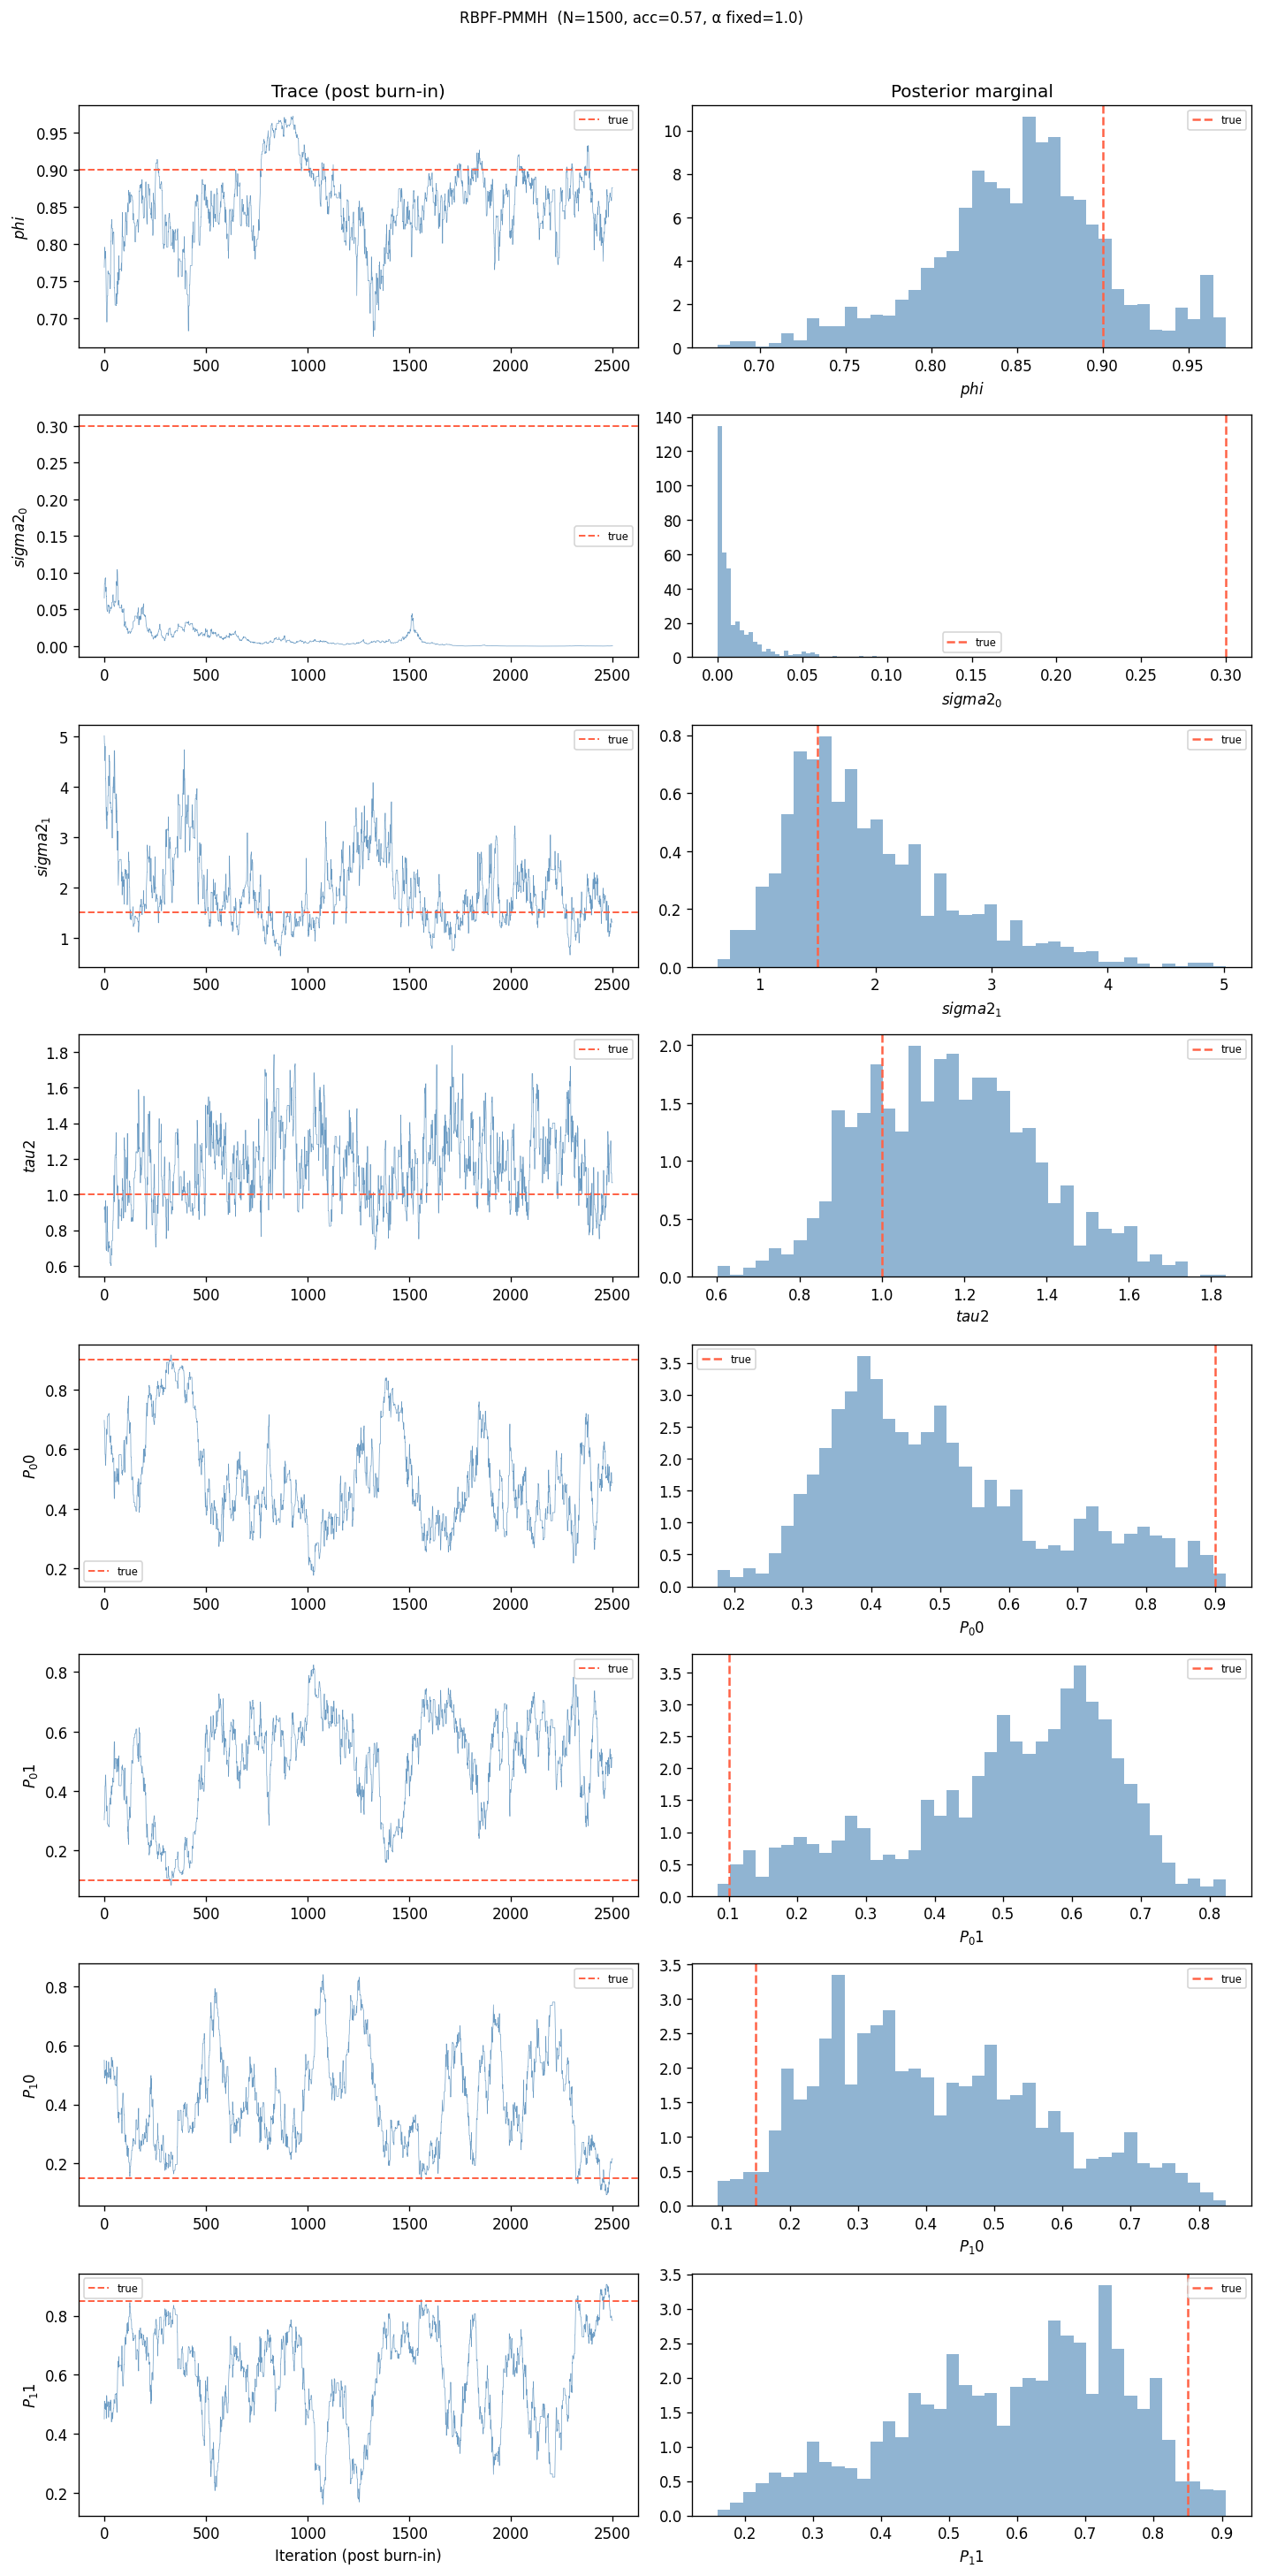

In [52]:
# ── Summary table ─────────────────────────────────────────────────────────────
names_rs = list(model_rs_est.params_dict.keys())   # phi, sigma2_0, sigma2_1, tau2
print(f"\n{'Param':<12} {'True':>8} {'Post mean':>10} {'Post std':>10} {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(names_rs):
    samp = constrained_rs[:, k]
    ess  = chain_ess(samp)
    print(f"{name:<12} {TRUE_RS.get(name, float('nan')):>8.4f} "
          f"{samp.mean():>10.4f} {samp.std():>10.4f} {ess:>8.1f}")

# ── Trace and posterior plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(len(names_rs), 2, figsize=(12, 3 * len(names_rs)))

for k, name in enumerate(names_rs):
    samp = constrained_rs[:, k]
    tv   = TRUE_RS.get(name)

    axes[k, 0].plot(samp, lw=0.4, color='steelblue', alpha=0.8)
    if tv is not None:
        axes[k, 0].axhline(tv, color='tomato', ls='--', lw=1.2, label='true')
        axes[k, 0].legend(fontsize=7)
    axes[k, 0].set_ylabel(f'${name}$')
    if k == 0:
        axes[k, 0].set_title('Trace (post burn-in)')

    axes[k, 1].hist(samp, bins=40, density=True, color='steelblue', alpha=0.6)
    if tv is not None:
        axes[k, 1].axvline(tv, color='tomato', ls='--', lw=1.5, label='true')
        axes[k, 1].legend(fontsize=7)
    axes[k, 1].set_xlabel(f'${name}$')
    if k == 0:
        axes[k, 1].set_title('Posterior marginal')

axes[-1, 0].set_xlabel('Iteration (post burn-in)')
fig.suptitle(
    f'RBPF-PMMH  (N={N_PART_RS}, acc={acc_rs.mean():.2f}, '
    f'α fixed={alpha_rs})',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

## Section IX: Other Extensions — Model Misspecification

A correctly specified model is rarely available in practice. We test the robustness of the linear Gaussian estimator by applying it to observations generated from two misspecified processes: a student-t model (heavy-tailed observation noise) and a linear ARMA model (moving-average dependence in the innovations). We compare the estimated parameters and log-likelihoods against the correctly-specified baseline to quantify the cost of misspecification.

1. Gaussian estimator on data generated by a linear student-t model
2. Gaussian estimator on data generated by a linear ARMA model

Restart 0/2 best val: 440.7110466292961
Restart 1/2 best val: 440.7110466292961
MLEEstimator.fit  0.087s
Gaussian MLE on student-t data:
MLEResult  loglik=-440.7110  converged  n_evals=60
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.906716             —
  sigma2                1.806115             —
  tau2                  0.442716             —
Restart 0/2 best val: 377.2630142833811
Restart 1/2 best val: 377.26301428334966
MLEEstimator.fit  0.054s

Gaussian MLE on ARMA data:
MLEResult  loglik=-377.2630  converged  n_evals=56
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.855051             —
  sigma2                0.672099             —
  tau2                  0.665923             —

Dataset                LL at true θ    LL at

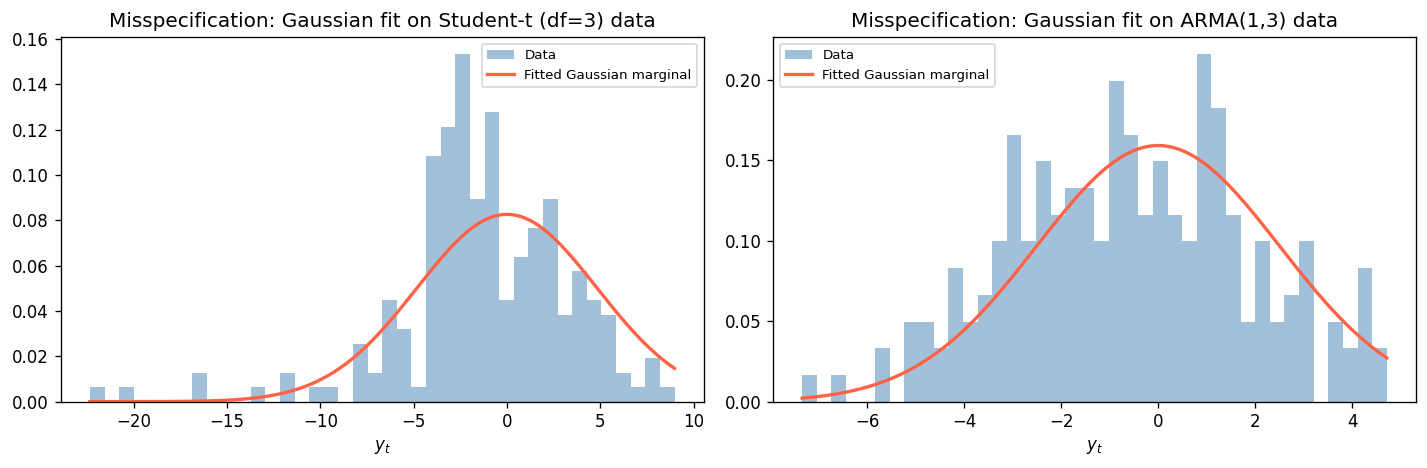

In [50]:
### 1. Model Misspecification: Gaussian Estimator on Student-t Data

# Generate data from a LinearTSSM (student-t observation noise, df=3)
T_ms   = 200
df_ms  = 3      # degrees of freedom — heavy tails
seed_ms = 77

model_t = LinearTSSM(
    alpha=alpha_true, tau=np.sqrt(tau2_true),
    phi=phi_true, sigma=np.sqrt(sigma2_true), df=df_ms, seed=seed_ms,
)
_, obs_t, _ = model_t.generate_data(T_ms)
obs_t_1d = obs_t.ravel()

# Fit the misspecified Gaussian model
model_gauss_t = FixedAlphaSSM(
    alpha_fixed=alpha_true, phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=seed_ms,
)
mle_gauss_t = MLEEstimator(model=model_gauss_t, data=obs_t_1d,
                             method='L-BFGS-B', n_restarts=2, seed=0)
res_gauss_t = mle_gauss_t.fit()
print("Gaussian MLE on student-t data:")
print(res_gauss_t.summary())

### 2. Model Misspecification: Gaussian Estimator on ARMA Data

model_arma = LinearARMASSM(
    phi=phi_true, alpha=alpha_true, c=0.0,
    theta_1=0.4, theta_2=0.2, theta_3=0.0,
    sigma=np.sqrt(sigma2_true), tau=np.sqrt(tau2_true), seed=seed_ms,
)
_, obs_arma, _ = model_arma.generate_data(T_ms)
obs_arma_1d = obs_arma.ravel()

model_gauss_arma = FixedAlphaSSM(
    alpha_fixed=alpha_true, phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=seed_ms,
)
mle_gauss_arma = MLEEstimator(model=model_gauss_arma, data=obs_arma_1d,
                                method='L-BFGS-B', n_restarts=2, seed=0)
res_gauss_arma = mle_gauss_arma.fit()
print("\nGaussian MLE on ARMA data:")
print(res_gauss_arma.summary())

# ── Comparison: true Gaussian loglik vs misspecified loglik ──────────────────
model_true_ref = FixedAlphaSSM(
    alpha_fixed=alpha_true, phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)
ll_true_params_t    = model_true_ref.log_likelihood(obs_t_1d)
ll_true_params_arma = model_true_ref.log_likelihood(obs_arma_1d)

print(f"\n{'Dataset':<20} {'LL at true θ':>14} {'LL at MLE θ':>14} {'Δ loglik':>10}")
print("─" * 62)
print(f"{'Student-t data':<20} {ll_true_params_t:>14.2f} {res_gauss_t.loglik:>14.2f}"
      f" {res_gauss_t.loglik - ll_true_params_t:>10.2f}")
print(f"{'ARMA data':<20} {ll_true_params_arma:>14.2f} {res_gauss_arma.loglik:>14.2f}"
      f" {res_gauss_arma.loglik - ll_true_params_arma:>10.2f}")

# ── Plot: observation histograms vs fitted Gaussian ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, obs_d, res_d, label in [
    (axes[0], obs_t_1d,    res_gauss_t,    f'Student-t (df={df_ms})'),
    (axes[1], obs_arma_1d, res_gauss_arma, 'ARMA(1,3)'),
]:
    ax.hist(obs_d, bins=40, density=True, alpha=0.5, color='steelblue', label='Data')
    xs = np.linspace(obs_d.min(), obs_d.max(), 200)
    # Marginal Gaussian under fitted params: N(0, alpha^2 * sigma2/(1-phi^2) + tau2)
    cp  = list(res_d.constrained_params)
    marg_var = alpha_true**2 * cp[1] / (1 - cp[0]**2) + cp[2]
    from scipy.stats import norm as sp_norm
    ax.plot(xs, sp_norm.pdf(xs, 0, np.sqrt(marg_var)), lw=2, color='tomato',
            label='Fitted Gaussian marginal')
    ax.set_title(f'Misspecification: Gaussian fit on {label} data')
    ax.set_xlabel('$y_t$'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
